In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from joblib import dump
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
import xgboost as xgb
from statsmodels.stats.diagnostic import het_white
import warnings
import json
warnings.filterwarnings("ignore")
scaler = StandardScaler()

In [132]:
data = pd.read_csv("gym_members_exercise_tracking.csv")
data

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [133]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [134]:
data.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


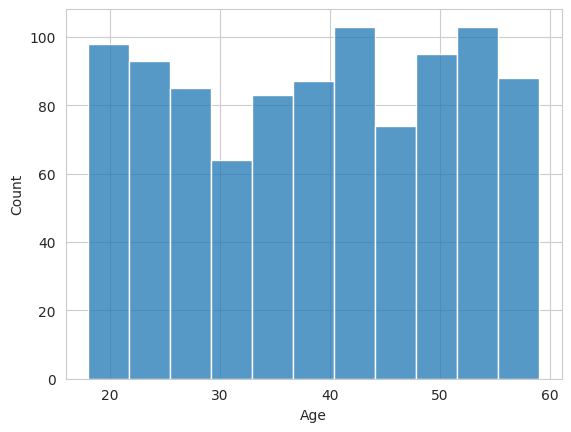

In [135]:
sns.histplot(data, x = "Age")
plt.show()

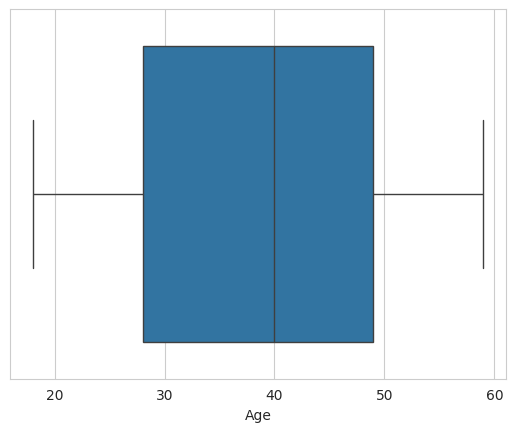

In [136]:
sns.boxplot(data, x = "Age")
plt.show()

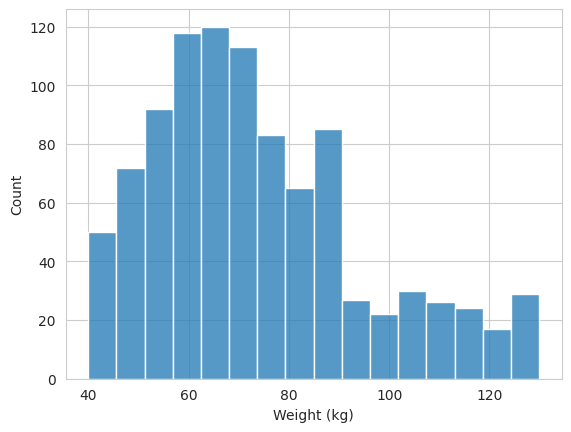

In [137]:
sns.histplot(data, x = "Weight (kg)")
plt.show()

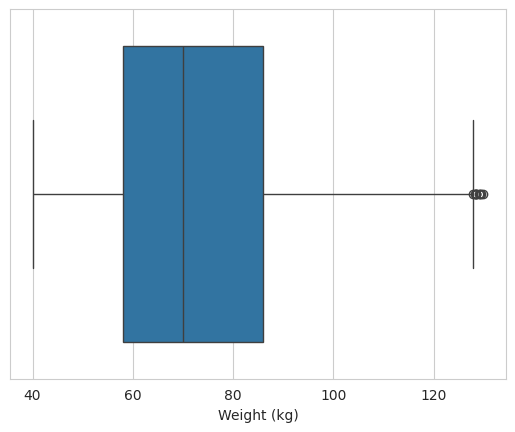

In [138]:
sns.boxplot(data, x = "Weight (kg)")
plt.show()

In [139]:
data[data["Weight (kg)"] > 129] 

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
122,56,Male,129.5,1.95,160,129,66,1.00,639.0,Strength,25.2,3.5,2,1,34.06
593,55,Male,129.9,1.73,187,155,60,0.69,529.0,Yoga,21.7,3.1,3,1,43.40
854,48,Male,129.2,1.61,193,167,62,1.06,876.0,Yoga,21.4,2.9,4,2,49.84


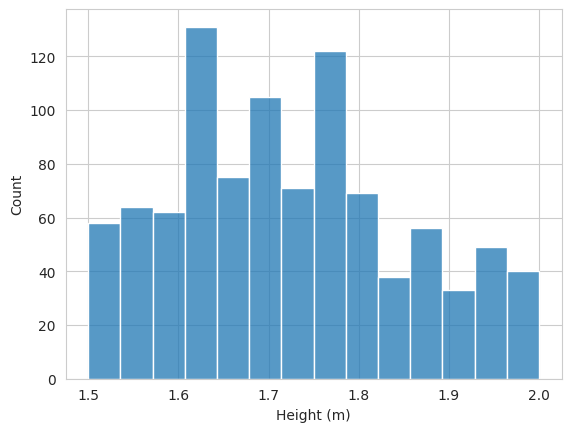

In [140]:
sns.histplot(data, x = "Height (m)")
plt.show()

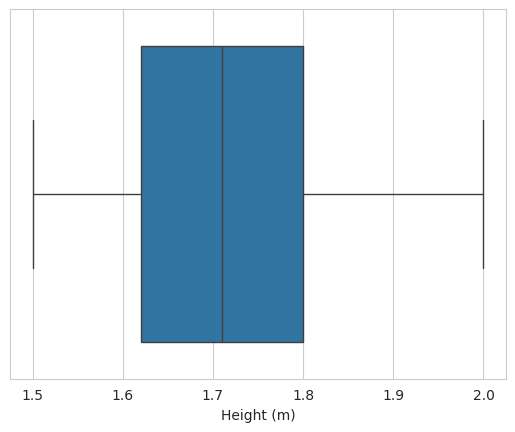

In [141]:
sns.boxplot(data, x = "Height (m)")
plt.show()

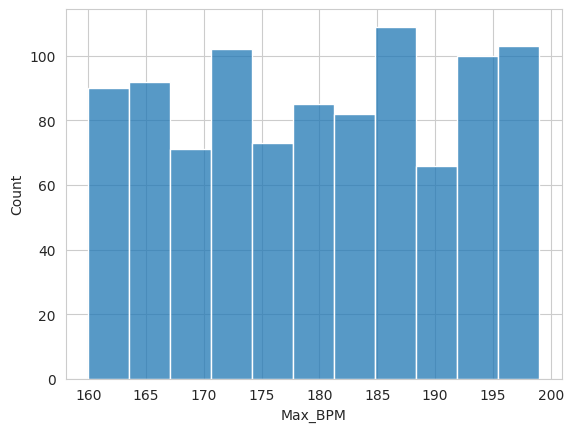

In [142]:
sns.histplot(data, x = "Max_BPM")
plt.show()

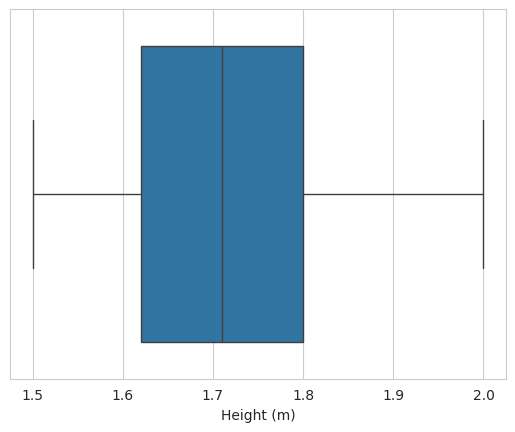

In [143]:
sns.boxplot(data, x = "Height (m)")
plt.show()

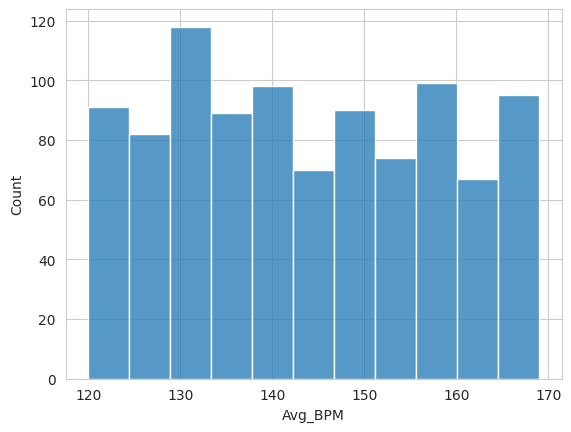

In [144]:
sns.histplot(data, x = "Avg_BPM")
plt.show()

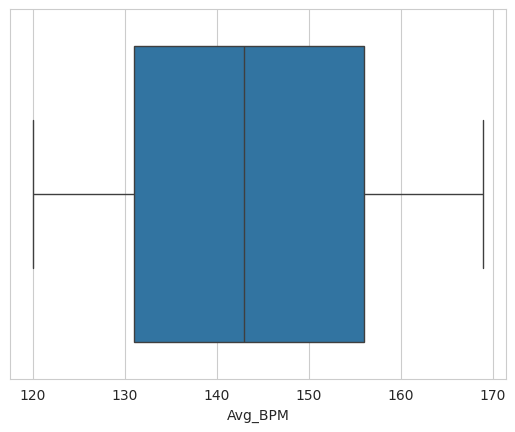

In [145]:
sns.boxplot(data, x = "Avg_BPM")
plt.show()

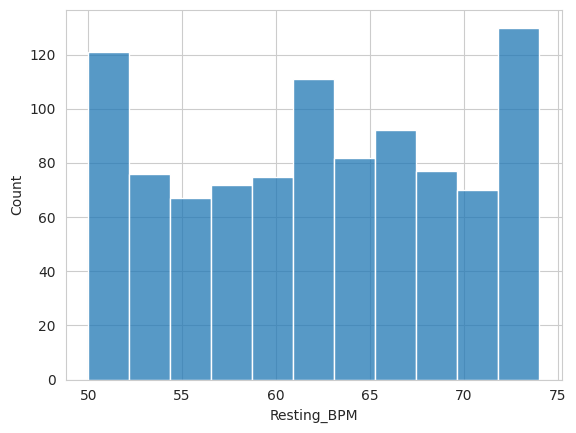

In [146]:
sns.histplot(data, x = "Resting_BPM")
plt.show()

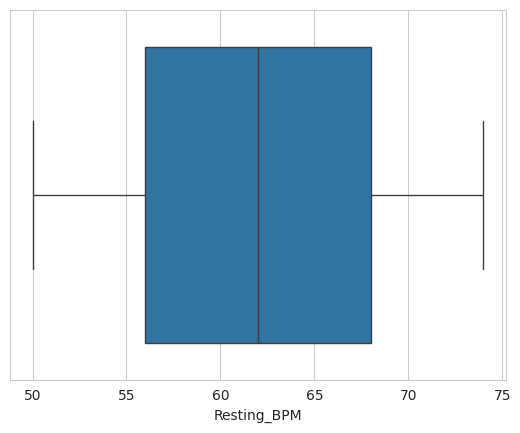

In [147]:
sns.boxplot(data, x = "Resting_BPM")
plt.show()

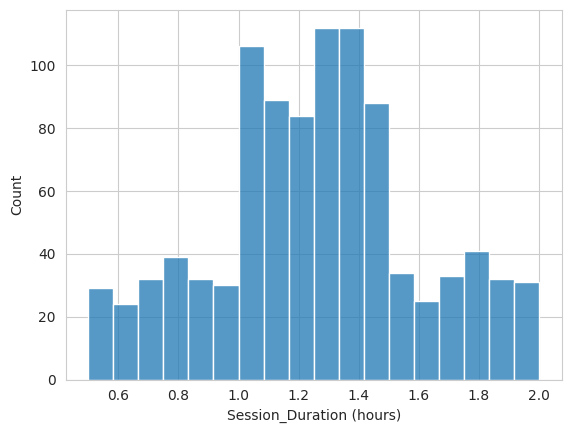

In [148]:
sns.histplot(data, x = "Session_Duration (hours)")
plt.show()

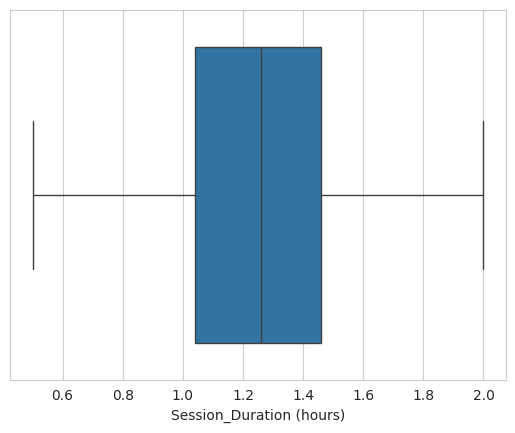

In [149]:
sns.boxplot(data, x = "Session_Duration (hours)")
plt.show()

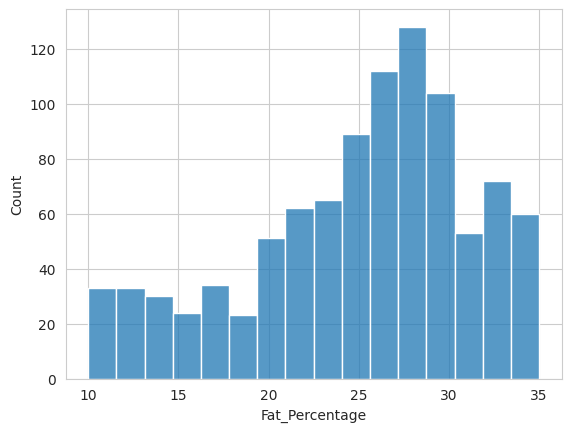

In [150]:
sns.histplot(data, x = "Fat_Percentage")
plt.show()

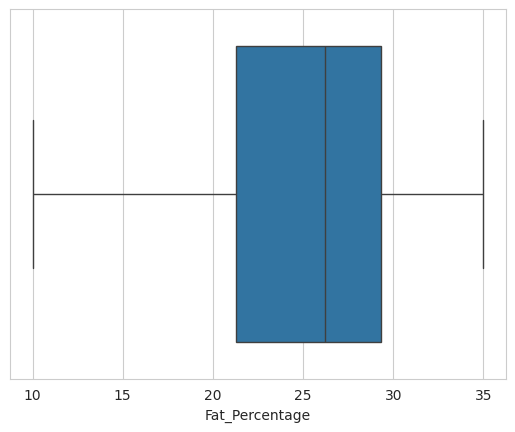

In [151]:
sns.boxplot(data, x = "Fat_Percentage")
plt.show()

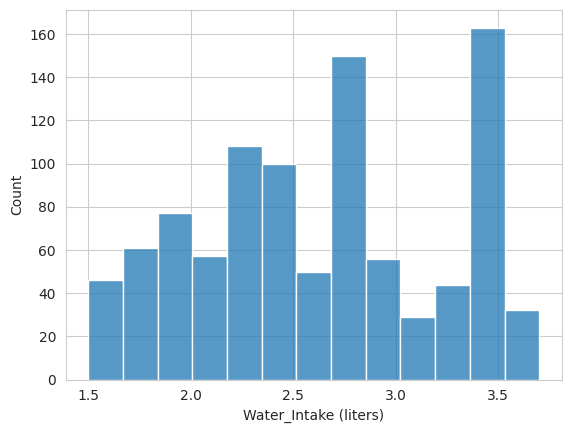

In [152]:
sns.histplot(data, x = "Water_Intake (liters)")
plt.show()

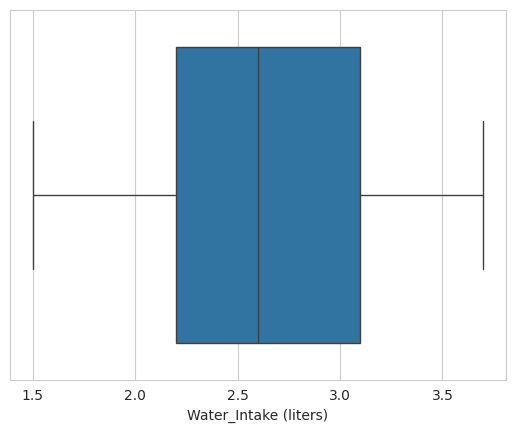

In [153]:
sns.boxplot(data, x = "Water_Intake (liters)")
plt.show()

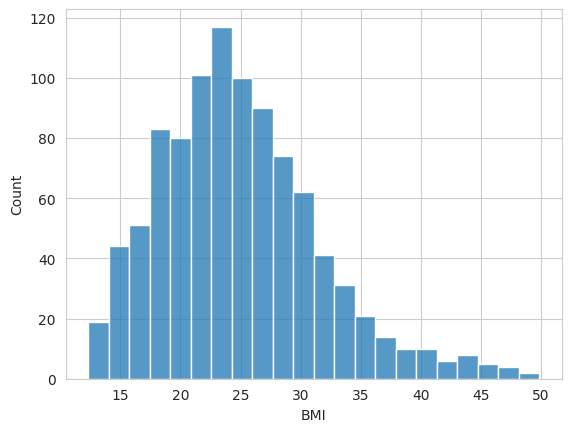

In [154]:
sns.histplot(data, x = "BMI")
plt.show()

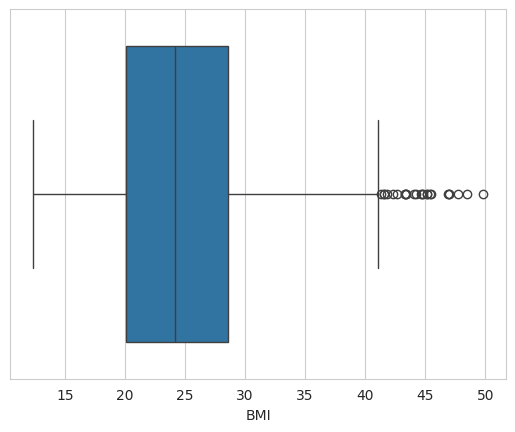

In [155]:
sns.boxplot(data, x = "BMI")
plt.show()

In [156]:
data[data["BMI"] > 42]

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
10,41,Male,120.8,1.67,188,146,54,0.82,593.0,HIIT,20.5,3.0,2,1,43.31
12,57,Male,112.5,1.61,195,165,61,1.24,1013.0,Cardio,22.1,2.7,3,2,43.40
35,26,Male,127.6,1.73,167,160,62,1.32,1162.0,Strength,27.3,2.9,3,1,42.63
55,23,Male,114.8,1.60,182,163,60,1.47,1318.0,Cardio,21.7,2.7,4,2,44.84
133,21,Male,125.2,1.66,196,159,60,1.38,1207.0,HIIT,29.8,3.4,3,2,45.43
251,33,Male,117.0,1.61,166,130,55,1.04,744.0,HIIT,25.1,2.4,3,2,45.14
261,57,Male,126.8,1.63,161,133,73,0.96,632.0,Yoga,20.8,2.1,2,1,47.72
291,55,Male,128.4,1.68,178,165,52,1.13,923.0,Cardio,20.4,2.6,4,2,45.49
302,36,Male,123.7,1.69,185,138,73,1.30,987.0,Cardio,20.4,2.1,4,2,43.31
345,43,Male,127.7,1.69,171,155,53,1.14,875.0,Cardio,24.1,2.9,3,2,44.71


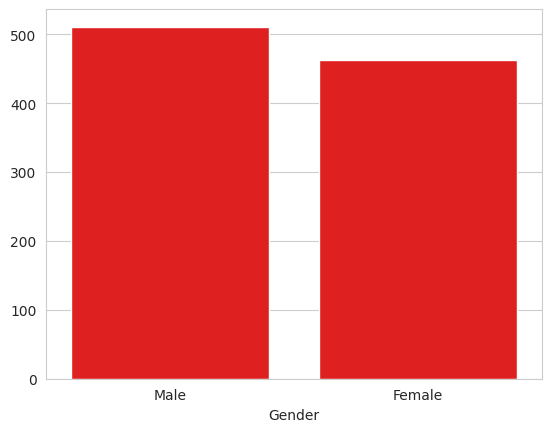

In [157]:
sns.barplot(x=data["Gender"].value_counts().index, 
            y=data["Gender"].value_counts().values, 
            color="red")
plt.show()

In [158]:
male = data[data["Gender"] == "Male"]
female = data[data["Gender"] == "Female"]

In [159]:
male.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,38.998043,85.531115,1.793405,179.996086,143.898239,62.320939,1.252446,944.455969,22.553816,3.007436,3.305284,1.812133,26.886967
std,12.045258,21.788629,0.117081,11.678873,14.300193,7.403943,0.344297,286.590987,5.729882,0.494146,0.927125,0.740912,7.630492
min,18.000000,45.000000,1.600000,160.000000,120.000000,50.000000,0.510000,331.000000,10.000000,2.000000,2.000000,1.000000,12.320000
25%,29.000000,69.750000,1.690000,170.000000,132.000000,56.000000,1.040000,742.000000,20.700000,2.600000,3.000000,1.000000,21.160000
50%,40.000000,85.300000,1.790000,180.000000,143.000000,63.000000,1.270000,937.000000,23.800000,3.100000,3.000000,2.000000,26.220000
75%,49.000000,101.600000,1.890000,189.000000,157.000000,68.500000,1.450000,1138.500000,27.200000,3.500000,4.000000,2.000000,31.725000
max,59.000000,129.900000,2.000000,199.000000,169.000000,74.000000,2.000000,1783.000000,30.000000,3.700000,5.000000,3.000000,49.840000


In [160]:
female.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,38.335498,60.939827,1.644242,179.759740,143.621212,62.114719,1.260823,862.248918,27.656710,2.205411,3.339827,1.807359,22.727835
std,12.332962,10.237671,0.086710,11.365199,14.408716,7.247547,0.341950,249.614915,5.708223,0.388323,0.897873,0.739137,4.475390
min,18.000000,40.000000,1.500000,160.000000,120.000000,50.000000,0.500000,303.000000,15.000000,1.500000,2.000000,1.000000,12.470000
25%,28.000000,54.050000,1.570000,170.000000,131.000000,56.000000,1.040000,710.250000,25.625000,1.900000,3.000000,1.000000,19.432500
50%,39.000000,61.350000,1.640000,180.000000,143.000000,62.000000,1.260000,867.000000,28.900000,2.200000,3.000000,2.000000,22.925000
75%,49.750000,69.175000,1.720000,190.000000,156.000000,68.000000,1.460000,1016.000000,32.200000,2.600000,4.000000,2.000000,26.050000
max,59.000000,79.900000,1.800000,199.000000,169.000000,74.000000,1.990000,1625.000000,35.000000,2.700000,5.000000,3.000000,35.040000


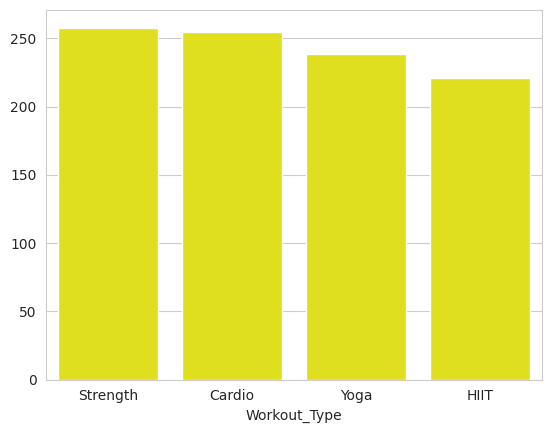

In [161]:
sns.barplot(x=data["Workout_Type"].value_counts().index, 
            y=data["Workout_Type"].value_counts().values, 
            color="yellow")
plt.show()

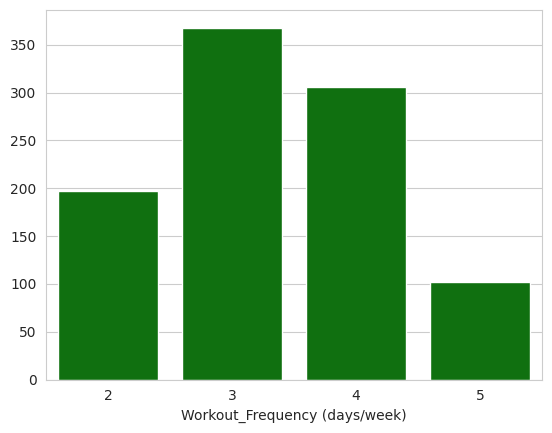

In [162]:
sns.barplot(x=data["Workout_Frequency (days/week)"].value_counts().index, 
            y=data["Workout_Frequency (days/week)"].value_counts().values, 
            color="green")
plt.show()

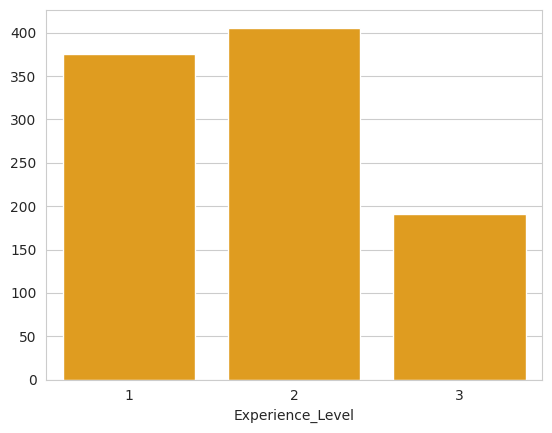

In [163]:
sns.barplot(x=data["Experience_Level"].value_counts().index, 
            y=data["Experience_Level"].value_counts().values, 
            color="orange")
plt.show()

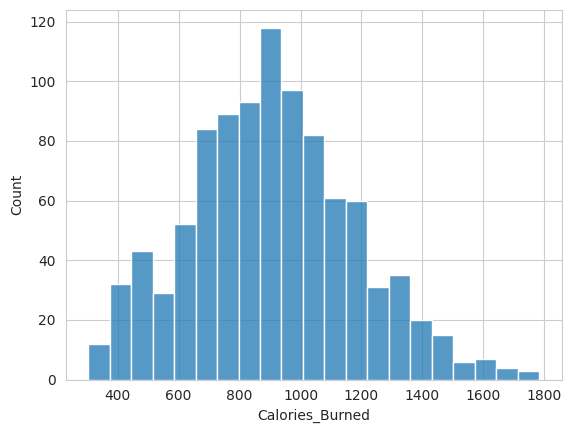

In [164]:
sns.histplot(data, x = "Calories_Burned")
plt.show()

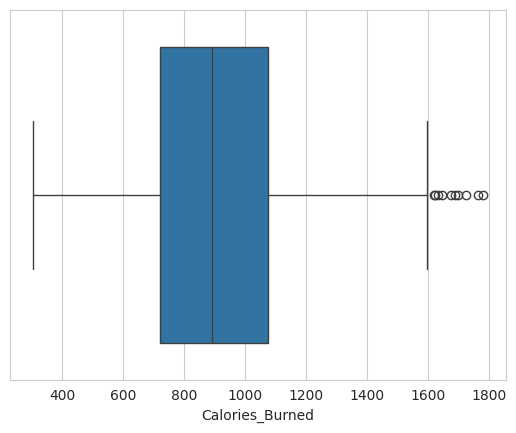

In [165]:
sns.boxplot(data, x = "Calories_Burned")
plt.show()

In [166]:
data[data["Calories_Burned"] > 1600] 

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
90,25,Male,81.5,1.61,170,159,63,1.93,1688.0,HIIT,10.9,3.5,4,3,31.44
99,24,Female,60.1,1.79,170,165,63,1.97,1625.0,Cardio,15.9,2.7,4,3,18.76
124,26,Male,86.2,1.68,189,157,72,1.97,1701.0,Strength,13.3,3.5,5,3,30.54
475,27,Male,89.3,1.64,192,162,64,1.82,1622.0,HIIT,12.1,3.5,4,3,33.20
511,39,Male,86.2,1.82,191,160,72,1.96,1725.0,Strength,10.2,3.5,5,3,26.02
572,36,Male,88.0,1.71,185,160,73,1.87,1646.0,HIIT,12.0,3.5,5,3,30.09
646,22,Male,88.5,1.62,174,162,69,1.88,1675.0,Strength,10.7,3.5,5,3,33.72
712,19,Male,82.4,1.96,174,169,62,1.90,1766.0,HIIT,10.1,3.5,5,3,21.45
728,47,Male,87.2,1.64,177,165,50,2.00,1634.0,Strength,15.0,3.5,4,3,32.42
910,32,Male,89.8,1.92,199,168,67,1.93,1783.0,Strength,10.6,3.5,4,3,24.36


In [167]:
data = data.rename(columns={
    "Weight (kg)": "Weight",
    "Height (m)": "Height",
    "Session_Duration (hours)": "Session_Duration",
    "Water_Intake (liters)": "Water_Intake",
    "Workout_Frequency (days/week)": "Workout_Frequency"
})
data

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake,Workout_Frequency,Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [168]:
data["Ex_Level_Workout_Freq"] = data["Experience_Level"] * data["Workout_Frequency"]
data["VO2_Max"] = 15.3 * (data["Max_BPM"] / data["Resting_BPM"])
data["HRR"] = data["Max_BPM"] - data["Resting_BPM"]
data["Water_Intake_Session_Duration"] = data["Water_Intake"] / data["Session_Duration"]
data["Fat_In_Kg"] = data["Weight"] * data["Fat_Percentage"] / 100
data["BMI_Label"] = ["Underweight" if bmi < 18.5 else 
                     "Normal_weight" if 18.5 <= bmi < 25 else 
                     "Overweight" if 25 <= bmi < 30 else 
                     "Obese" for bmi in data["BMI"]]
data["Session_Duration_Workout_Frequency"] = data["Session_Duration"] * data["Workout_Frequency"]

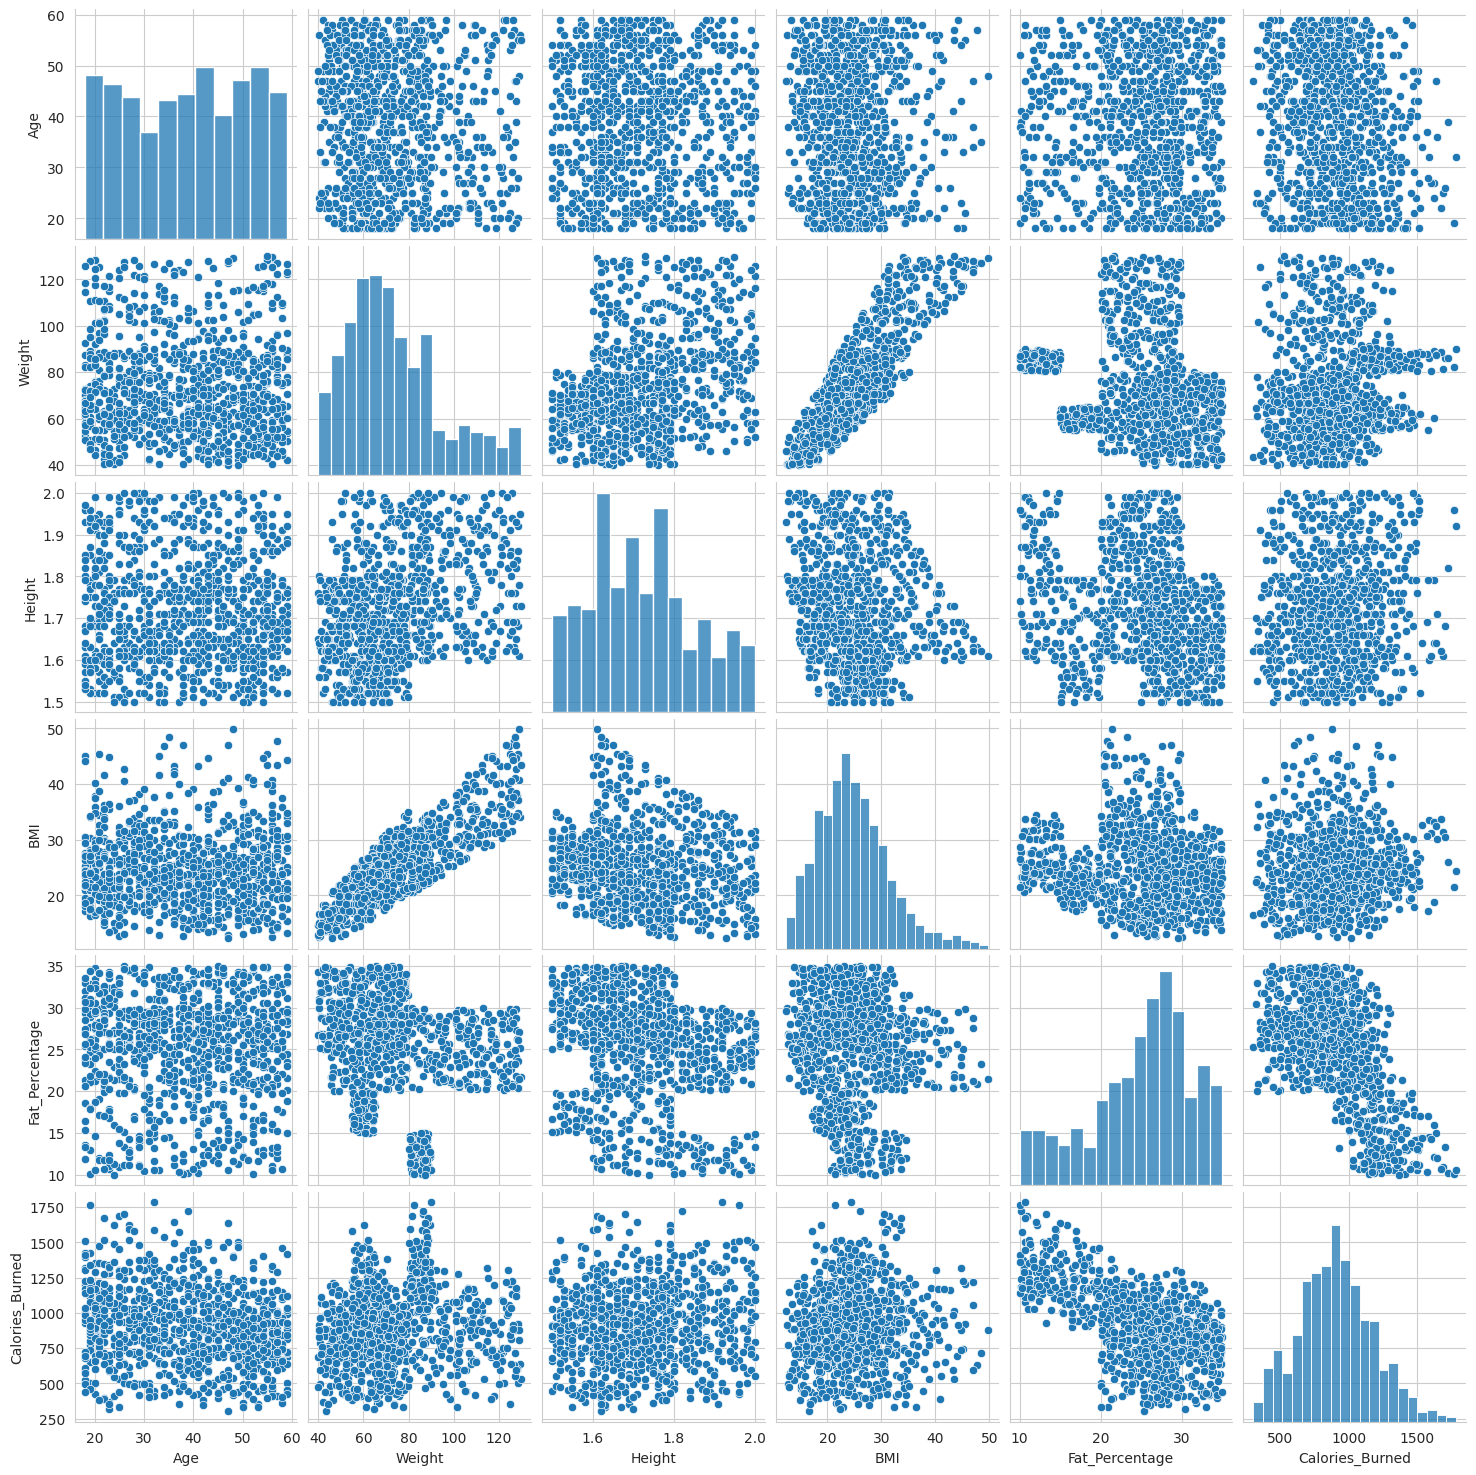

In [169]:
data1 = data[["Age", "Weight", "Height", "BMI", "Fat_Percentage","Calories_Burned"]]
sns.set_style("whitegrid")
sns.pairplot(data1)
plt.show()

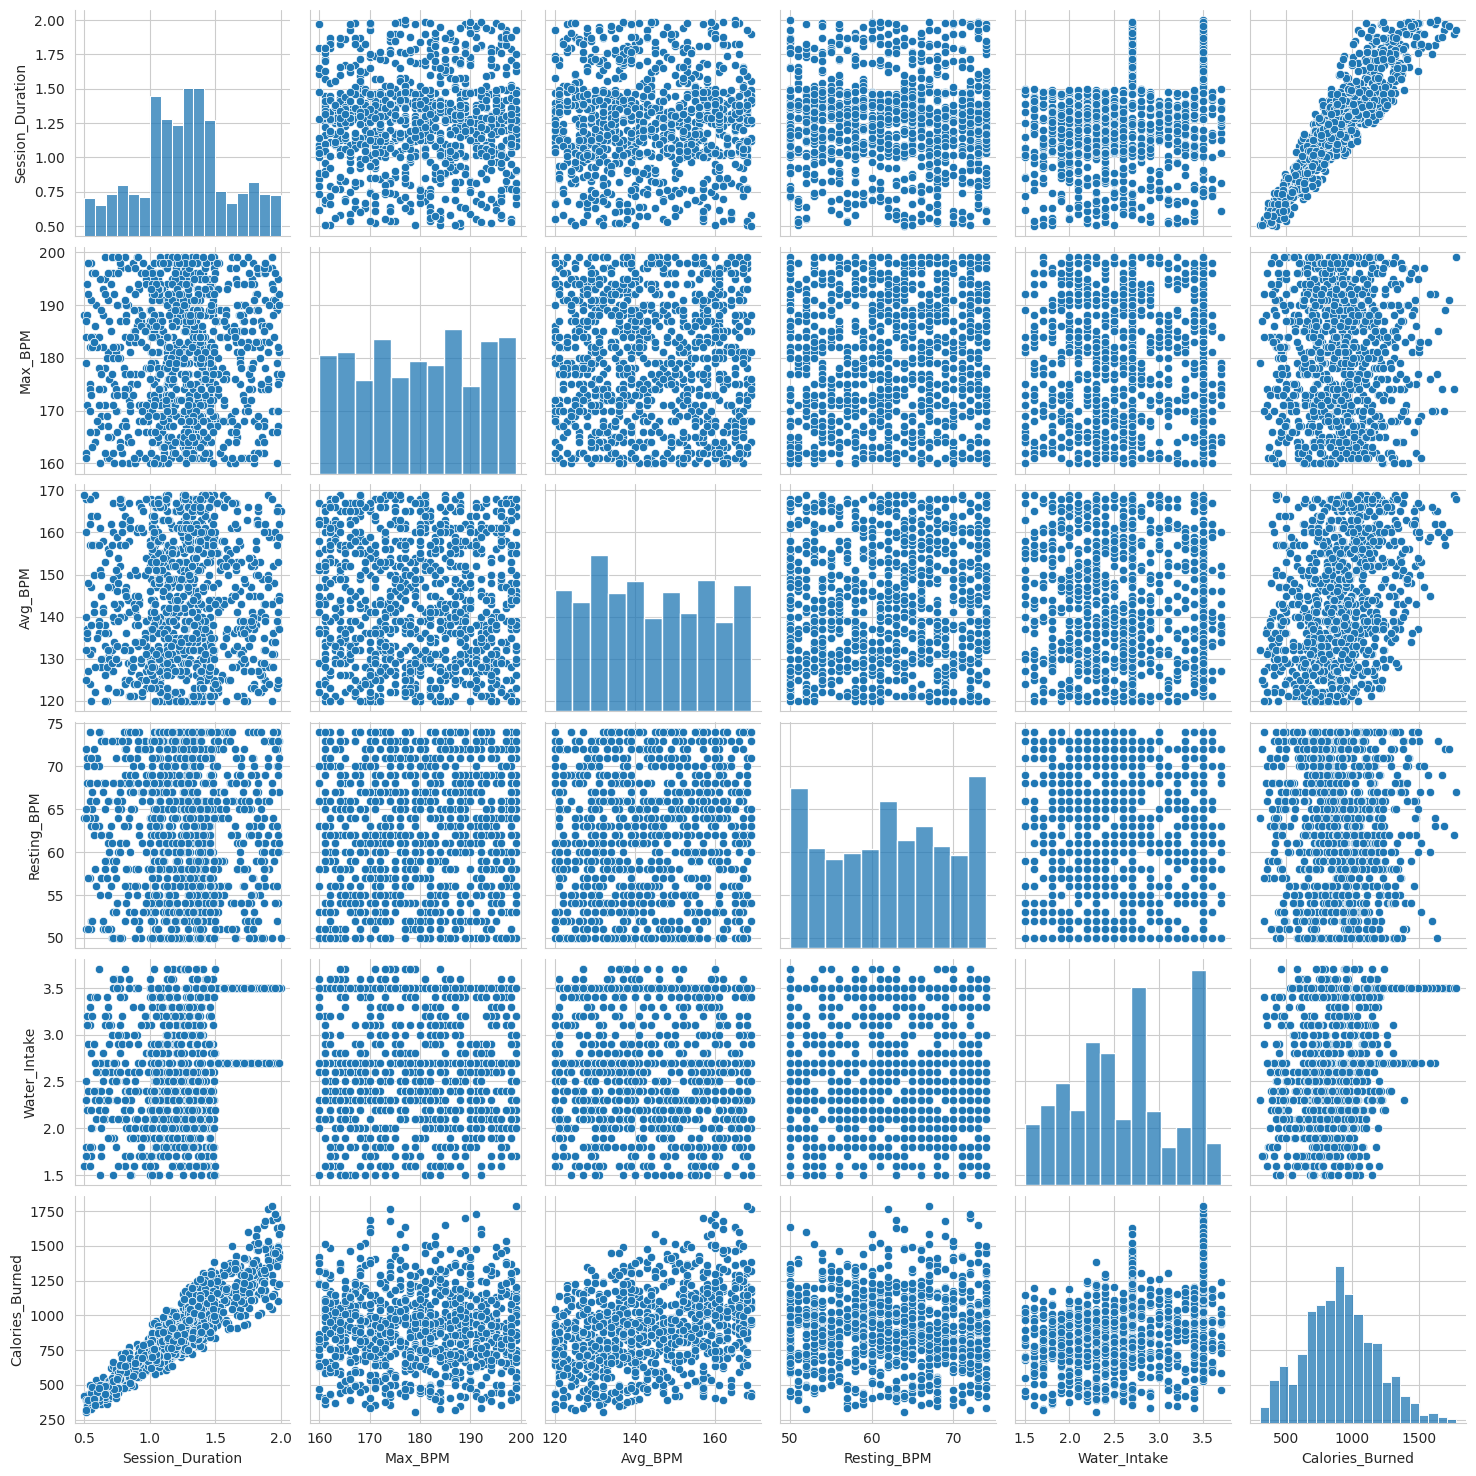

In [170]:
data2 = data[["Session_Duration", "Max_BPM", "Avg_BPM", "Resting_BPM", "Water_Intake",
              "Calories_Burned"]]
sns.set_style("whitegrid")
sns.pairplot(data2)
plt.show()

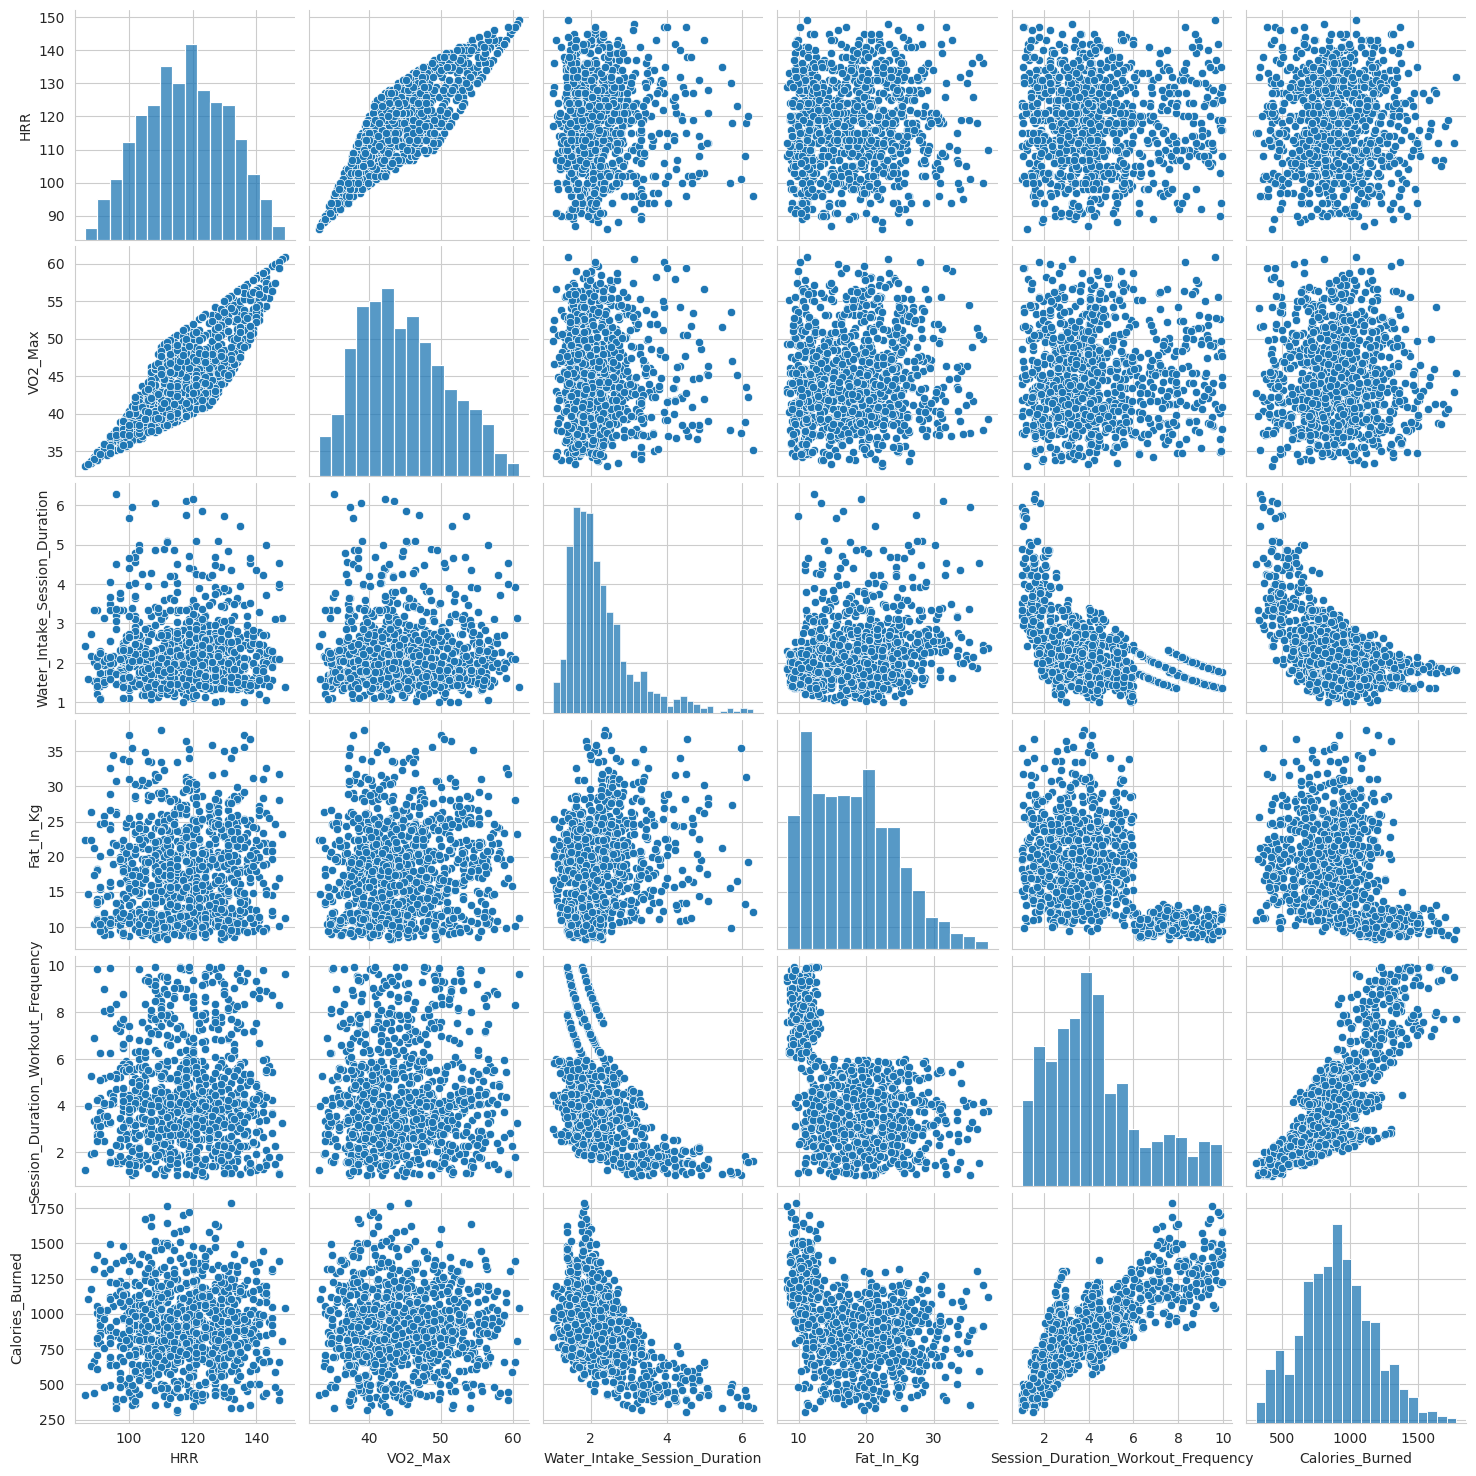

In [171]:
data3 = data[["HRR", "VO2_Max", "Water_Intake_Session_Duration", "Fat_In_Kg", "Session_Duration_Workout_Frequency", "Calories_Burned"]]
sns.set_style("whitegrid")
sns.pairplot(data3)
plt.show()

In [172]:
numeric_features = data.select_dtypes(include=['float64', 'int64']).columns.drop(['Calories_Burned', 'Experience_Level' ,
                                                                                  'Workout_Frequency', "Ex_Level_Workout_Freq"])
categorical_features = data.select_dtypes(include=['object']).columns.tolist() + ["Experience_Level"] + ["Workout_Frequency"] + ["Ex_Level_Workout_Freq"]

def plot_relationships(data, target, numeric_features, categorical_features):

    for feature in numeric_features:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(x=data[feature], y=data[target], alpha=0.7, edgecolor='k', color = "lightblue")
        plt.title(f"{target} vs {feature}")
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.grid(True)
        plt.show()

    for feature in categorical_features:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 1]})

        sns.boxplot(x=data[feature], y=data[target], ax=axes[0], color="green")
        axes[0].set_title(f"{target} by {feature} - Boxplot")
        axes[0].set_xlabel(feature)
        axes[0].set_ylabel(target)
        axes[0].grid(True)

        for category in data[feature].unique():
            sns.histplot(data=data[data[feature] == category], x=target, label=str(category), ax=axes[1], kde=True, alpha=0.5)
        axes[1].set_title(f"{target} Distribution by {feature} - Histogram")
        axes[1].set_xlabel(target)
        axes[1].set_ylabel("Frequency")
        axes[1].legend(title=feature)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

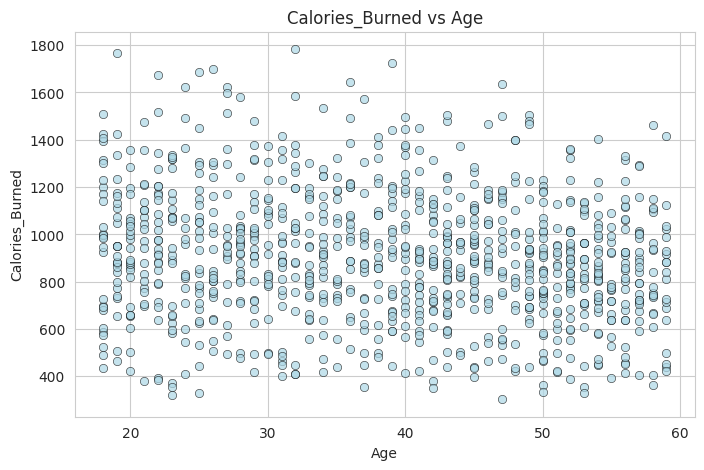

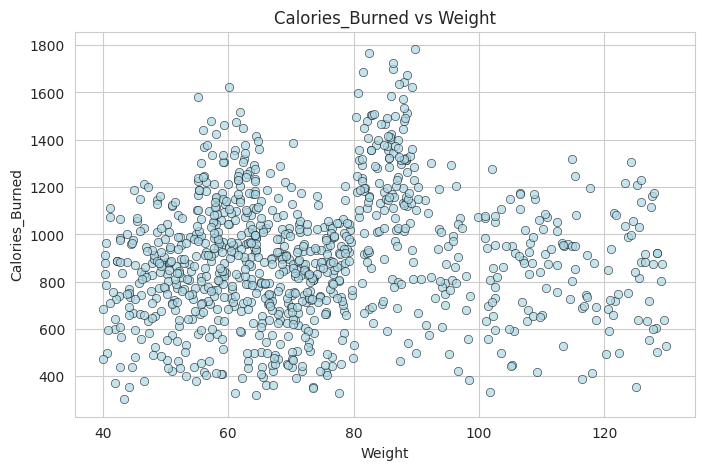

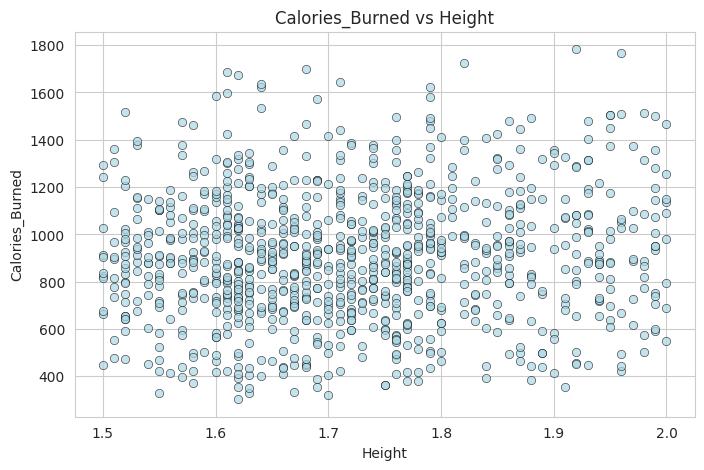

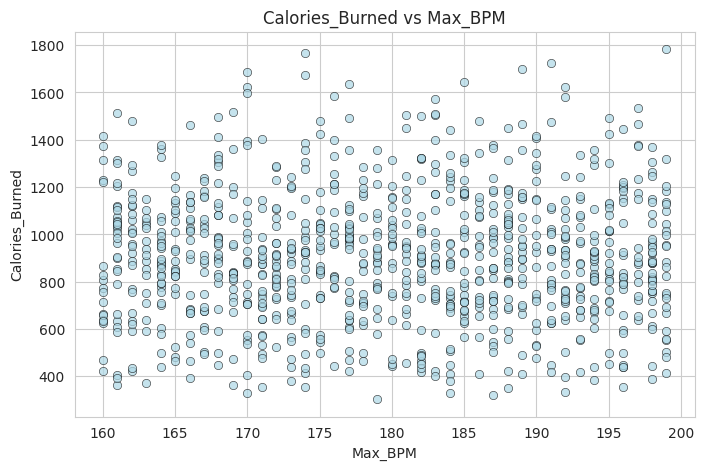

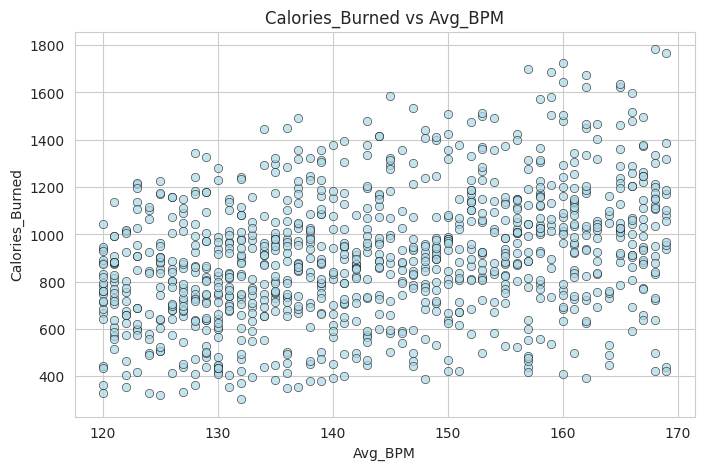

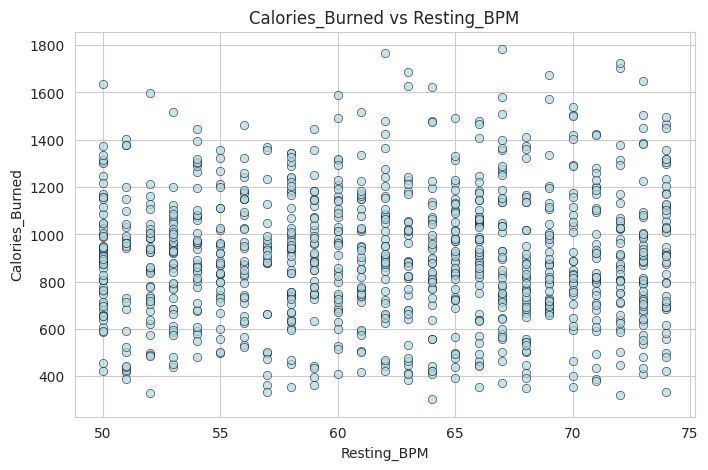

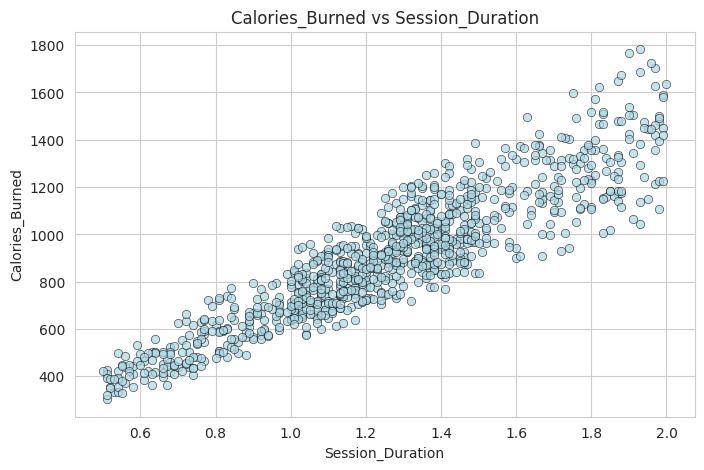

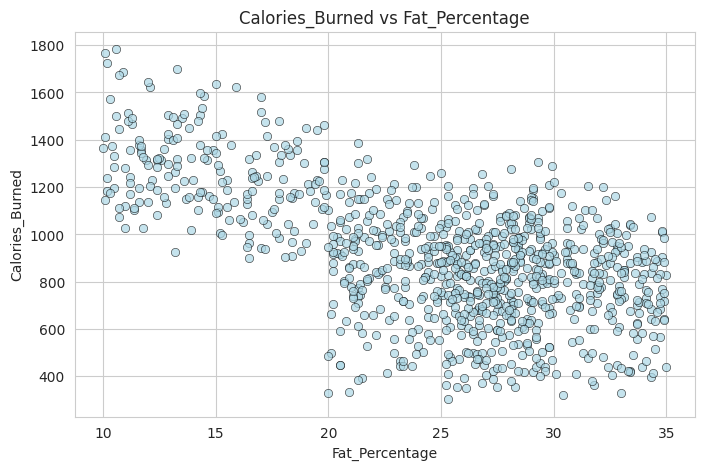

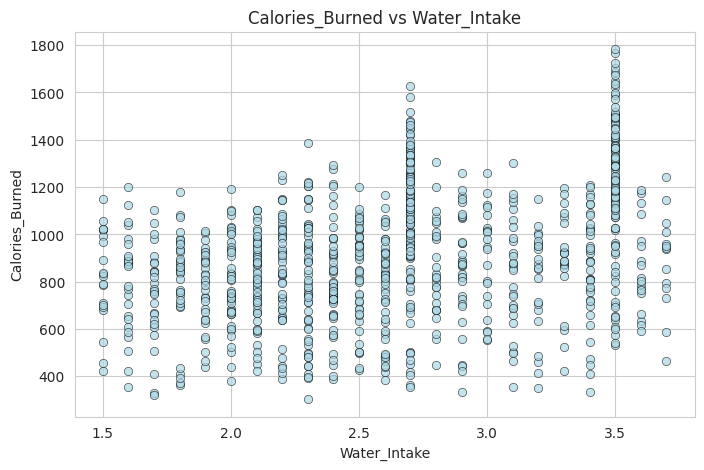

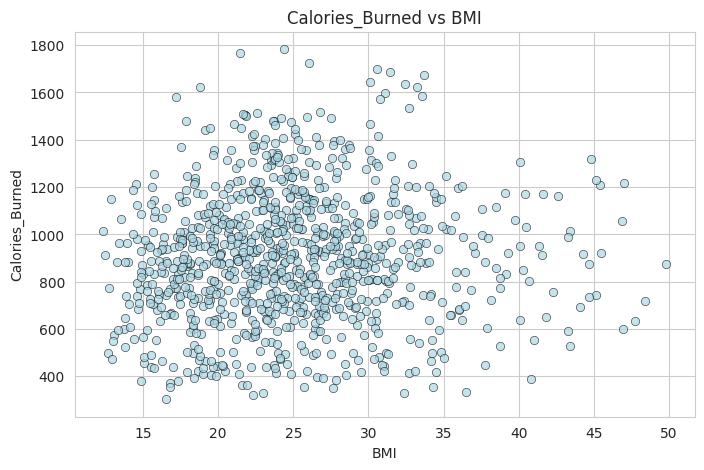

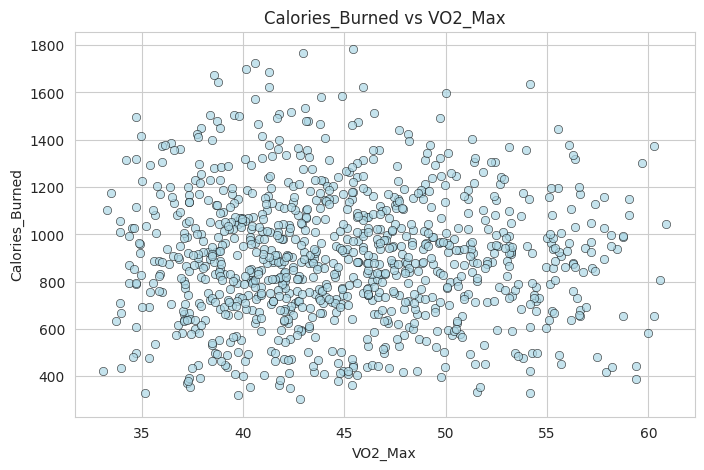

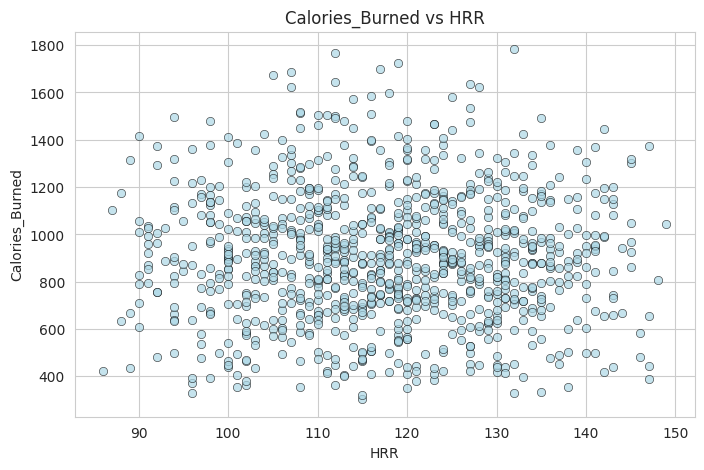

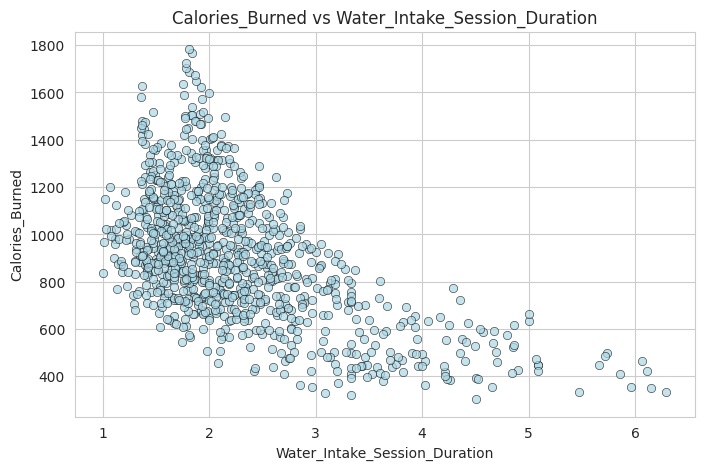

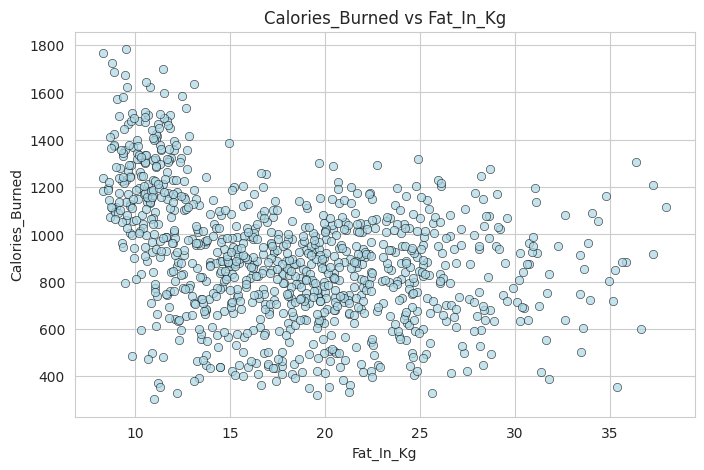

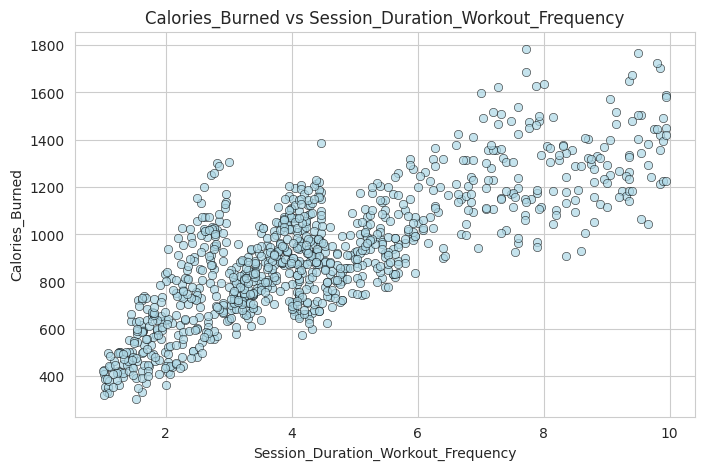

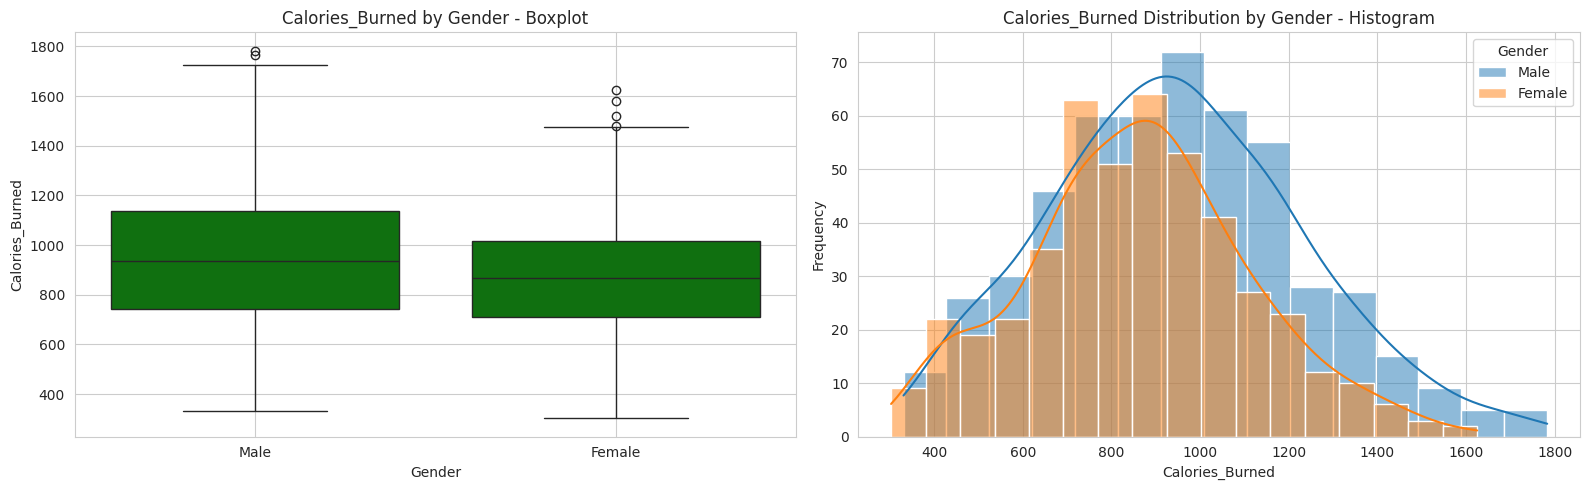

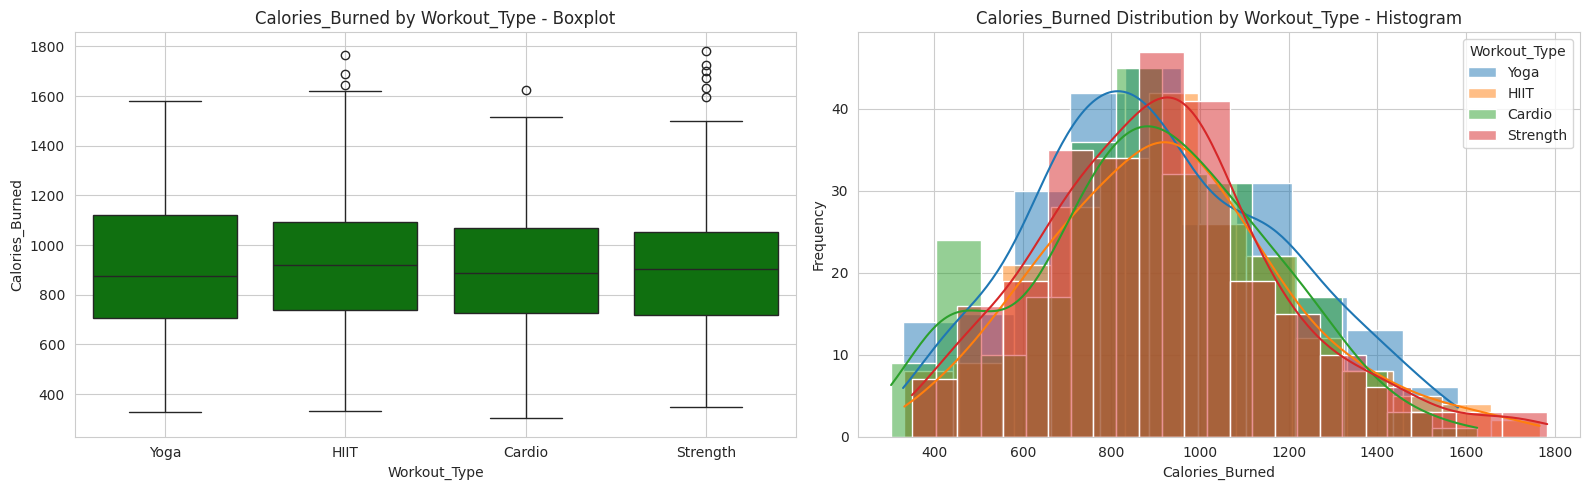

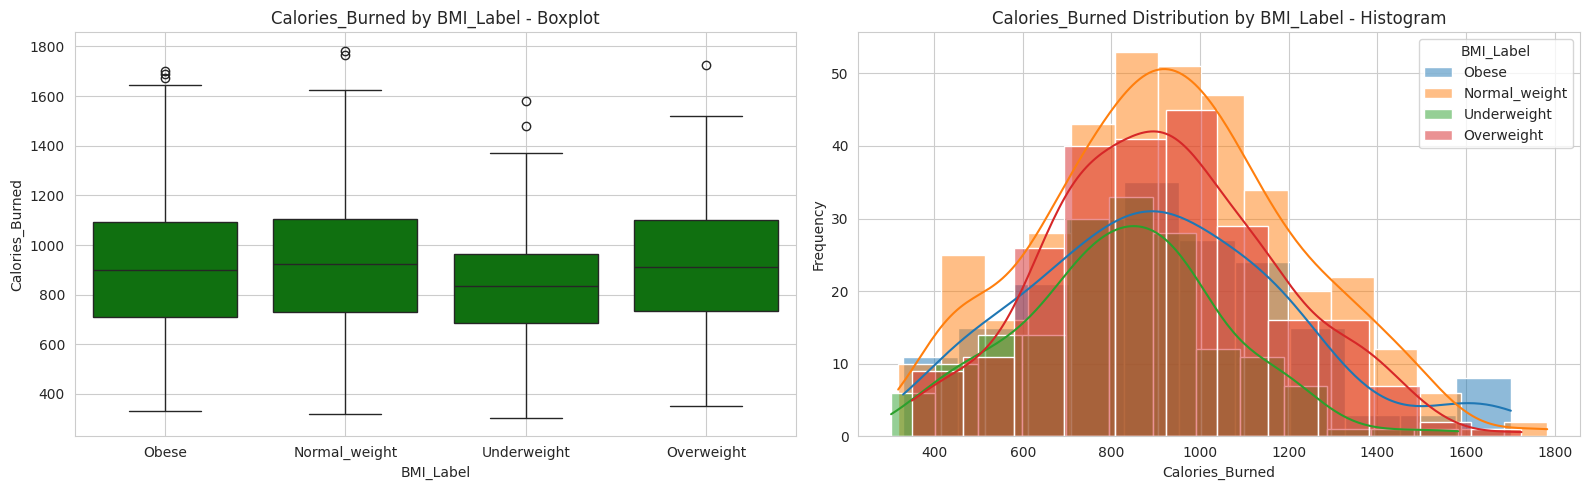

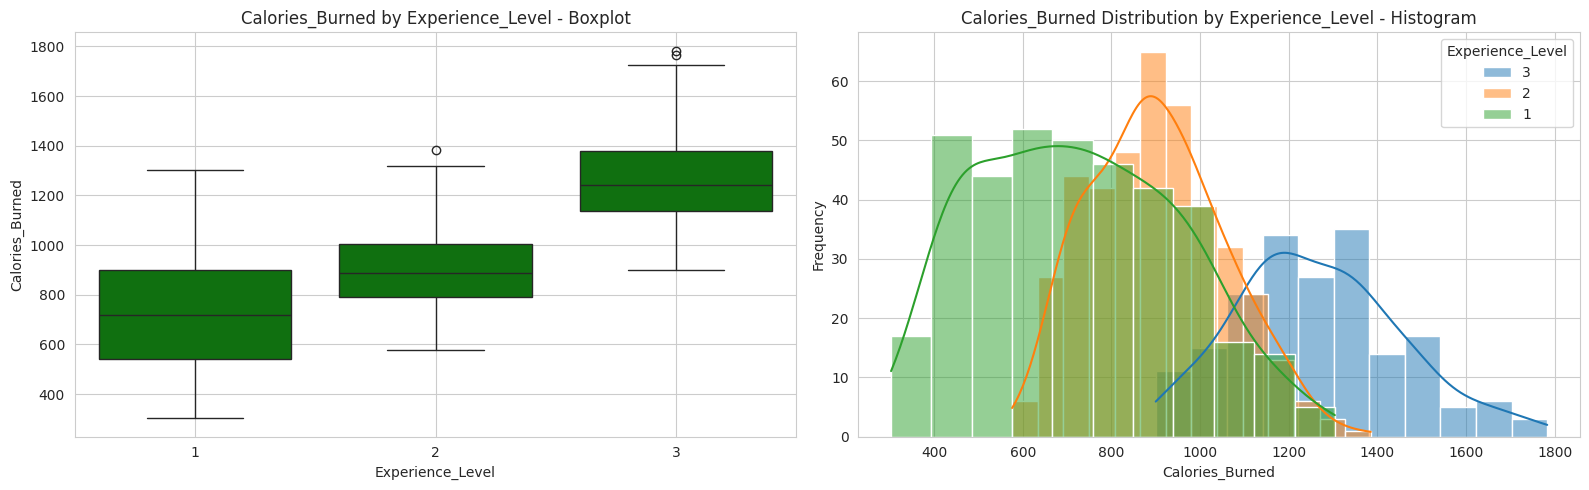

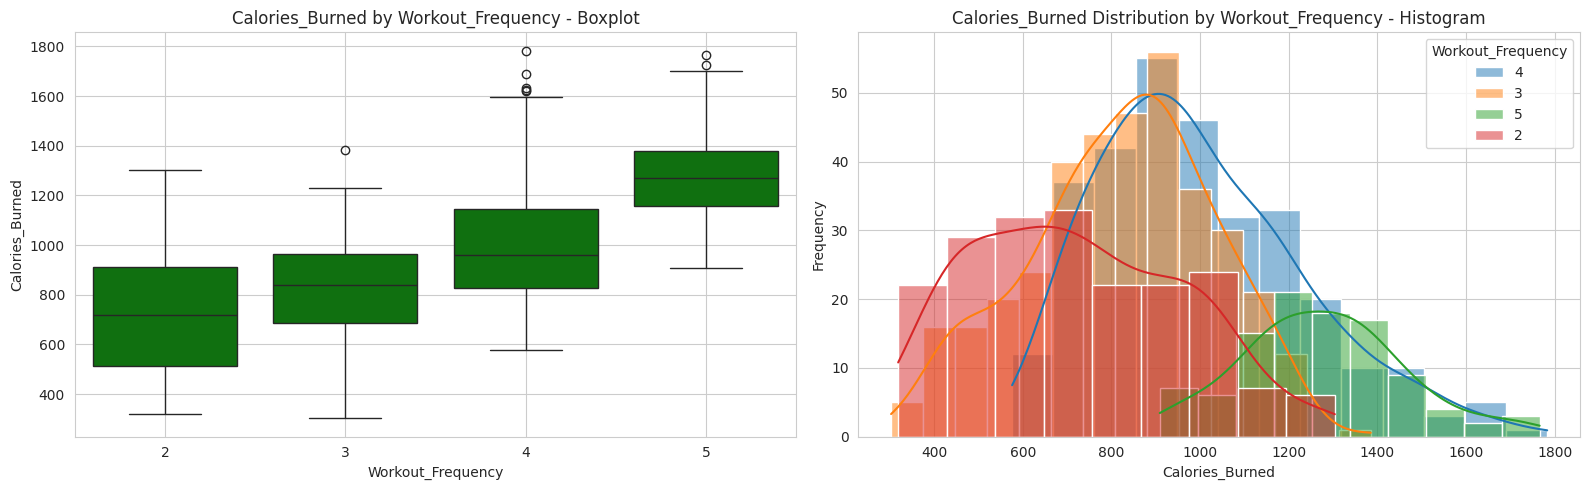

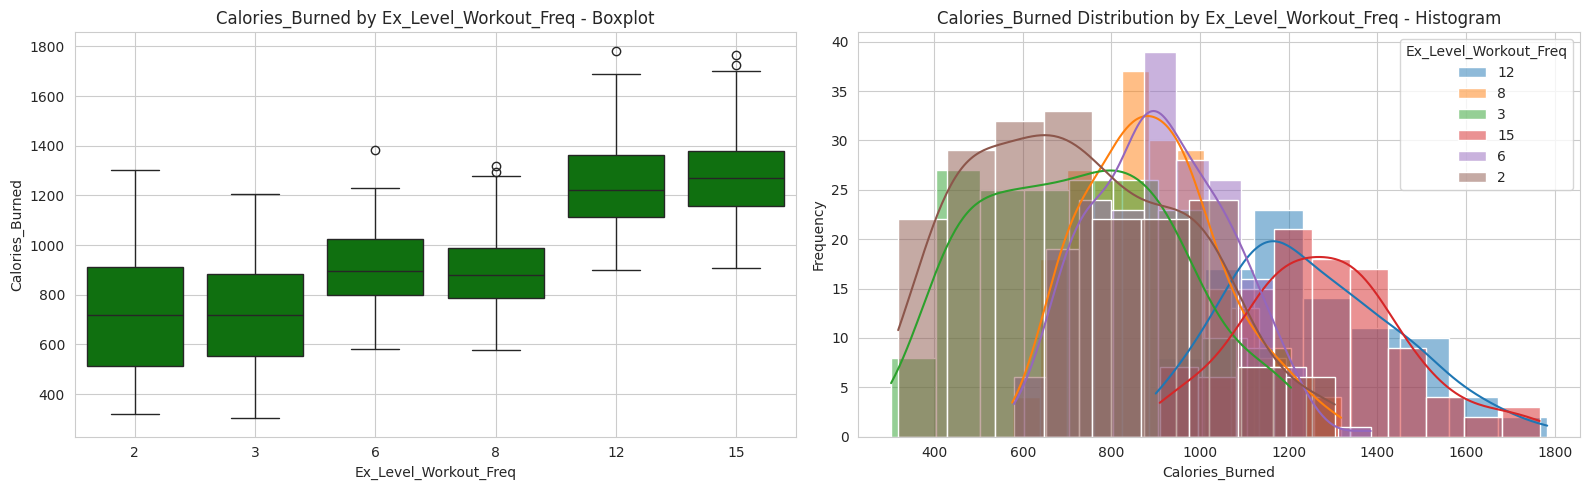

In [173]:
plot_relationships(data, target='Calories_Burned', numeric_features=numeric_features, categorical_features=categorical_features)

In [174]:
raw_data = data.copy(deep=True)
categorical_cols = ["Gender", "Workout_Type", "BMI_Label"]
data = pd.get_dummies(data, columns=categorical_cols, drop_first=False)
data_copy = data.copy(deep=True)
data

,Age,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,...,Gender_Female,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,...,False,True,False,False,False,True,False,True,False,False
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,...,True,False,False,True,False,False,False,True,False,False
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,...,True,False,True,False,False,False,True,False,False,False
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,...,False,True,False,False,True,False,False,False,False,True
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,...,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,...,False,True,False,False,True,False,False,False,True,False
969,25,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,...,False,True,False,False,True,False,False,False,True,False
970,59,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,...,True,False,True,False,False,False,True,False,False,False
971,32,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,...,False,True,False,True,False,False,False,True,False,False


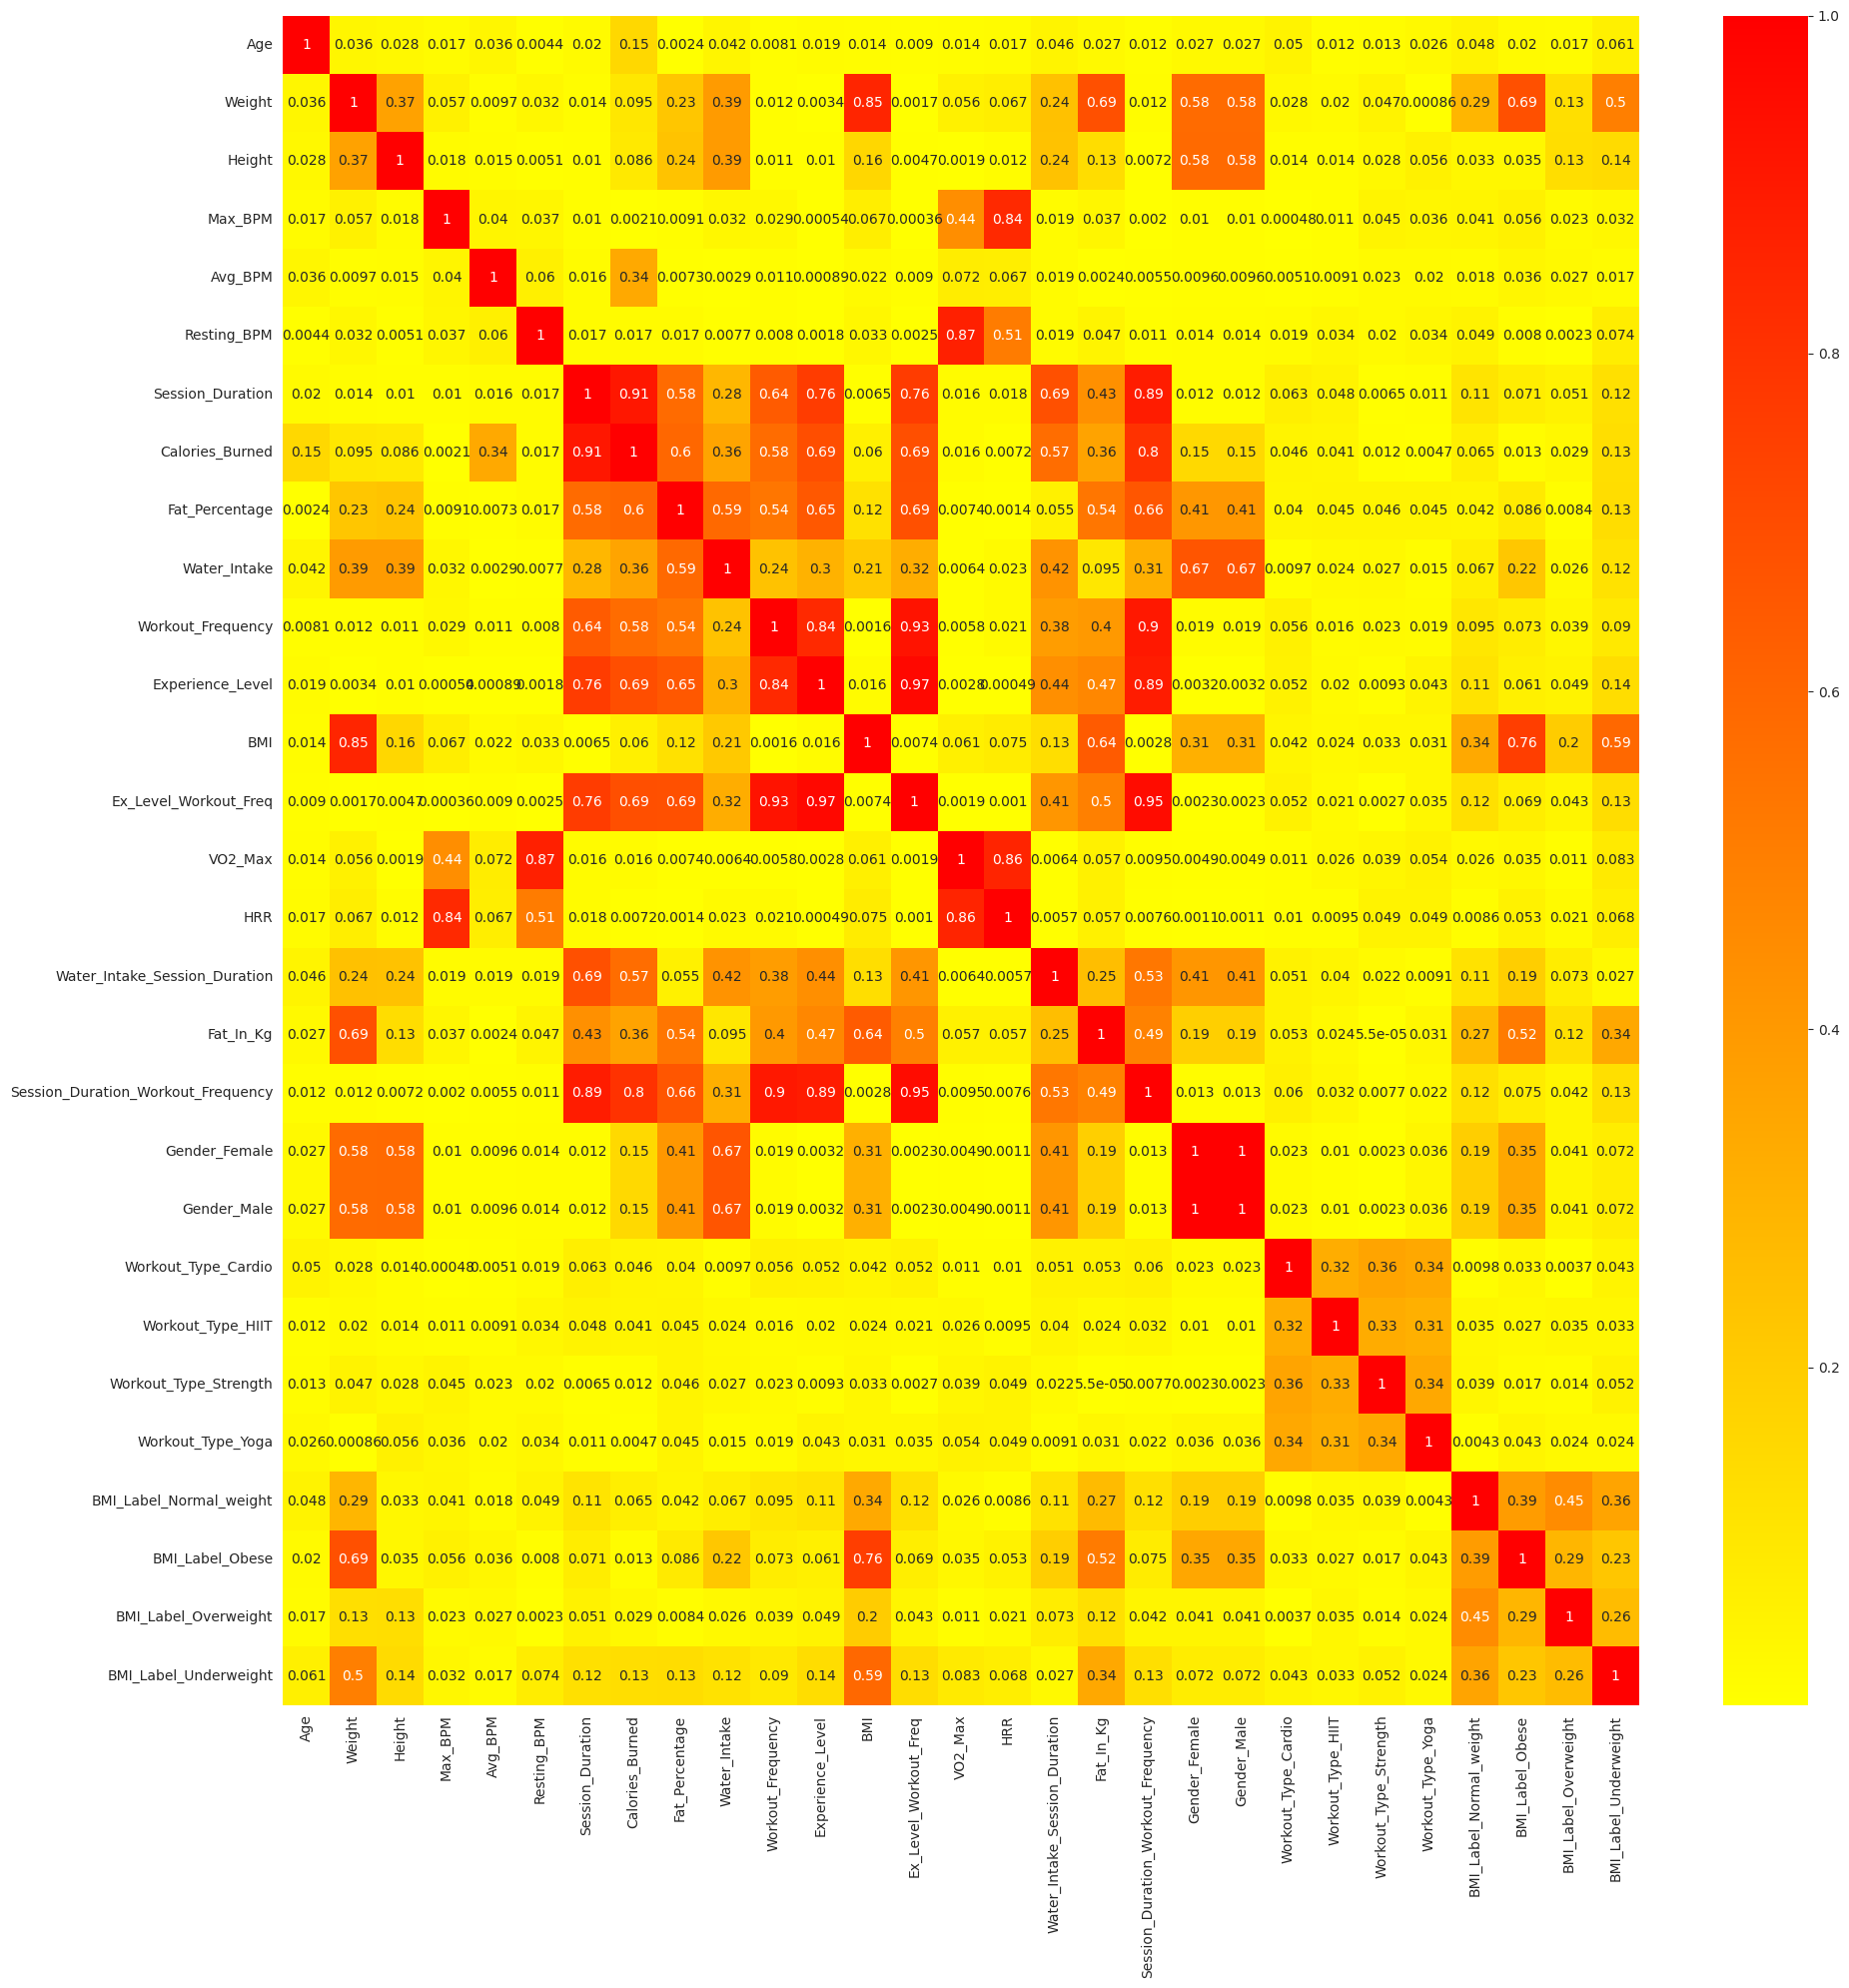

In [175]:
corr_matrix = data_copy.corr()
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(abs(corr_matrix), annot=True, cmap=plt.cm.autumn_r)
fig.tight_layout()
plt.show()

In [176]:
def cross_validate_model_with_train_test(data, formula, string, n_splits=5):
    train_mse_scores, test_mse_scores = [], []
    train_rmse_scores, test_rmse_scores = [], []
    train_mae_scores, test_mae_scores = [], []
    train_r2_scores, test_r2_scores = [], []
    train_rse_scores, test_rse_scores = [], []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(data):
        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]

        model = smf.ols(formula=formula, data=train_data).fit()

        train_predictions = model.predict(train_data)
        test_predictions = model.predict(test_data)

        if string == "Calories_Burned_SQRT":
            train_residuals = train_data[string]**2 - train_predictions**2
            test_residuals = test_data[string]**2 - test_predictions**2

            train_rss = np.sum(train_residuals ** 2)
            test_rss = np.sum(test_residuals ** 2)

            train_rse = np.sqrt(train_rss / (len(train_data) - model.df_model - 1))
            test_rse = np.sqrt(test_rss / (len(test_data) - model.df_model - 1))
        
            train_mse = mean_squared_error(train_data[string]**2, train_predictions**2)
            train_rmse = np.sqrt(train_mse)
            train_mae = mean_absolute_error(train_data[string]**2, train_predictions**2)
            train_r2 = r2_score(train_data[string]**2, train_predictions**2)

            test_mse = mean_squared_error(test_data[string]**2, test_predictions**2)
            test_rmse = np.sqrt(test_mse)
            test_mae = mean_absolute_error(test_data[string]**2, test_predictions**2)
            test_r2 = r2_score(test_data[string]**2, test_predictions**2)
        else:
            train_residuals = train_data[string] - train_predictions
            test_residuals = test_data[string] - test_predictions

            train_rss = np.sum(train_residuals ** 2)
            test_rss = np.sum(test_residuals ** 2)

            train_rse = np.sqrt(train_rss / (len(train_data) - model.df_model - 1))
            test_rse = np.sqrt(test_rss / (len(test_data) - model.df_model - 1))

            train_mse = mean_squared_error(train_data[string], train_predictions)
            train_rmse = np.sqrt(train_mse)
            train_mae = mean_absolute_error(train_data[string], train_predictions)
            train_r2 = r2_score(train_data[string], train_predictions)

            test_mse = mean_squared_error(test_data[string], test_predictions)
            test_rmse = np.sqrt(test_mse)
            test_mae = mean_absolute_error(test_data[string], test_predictions)
            test_r2 = r2_score(test_data[string], test_predictions)

        train_mse_scores.append(train_mse)
        test_mse_scores.append(test_mse)

        train_rmse_scores.append(train_rmse)
        test_rmse_scores.append(test_rmse)

        train_mae_scores.append(train_mae)
        test_mae_scores.append(test_mae)

        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)

        train_rse_scores.append(train_rse)
        test_rse_scores.append(test_rse)

    return {
        "Train_MSE": (np.mean(train_mse_scores), np.std(train_mse_scores)),
        "Test_MSE": (np.mean(test_mse_scores), np.std(test_mse_scores)),
        "Train_RMSE": (np.mean(train_rmse_scores), np.std(train_rmse_scores)),
        "Test_RMSE": (np.mean(test_rmse_scores), np.std(test_rmse_scores)),
        "Train_MAE": (np.mean(train_mae_scores), np.std(train_mae_scores)),
        "Test_MAE": (np.mean(test_mae_scores), np.std(test_mae_scores)),
        "Train_R2": (np.mean(train_r2_scores), np.std(train_r2_scores)),
        "Test_R2": (np.mean(test_r2_scores), np.std(test_r2_scores)),
        "Train_RSE": (np.mean(train_rse_scores), np.std(train_rse_scores)),
        "Test_RSE": (np.mean(test_rse_scores), np.std(test_rse_scores)),
    }


In [177]:
def cross_validate_model_with_train_test_regularization(data, model, target_column, n_splits=5):
    train_mse_scores, test_mse_scores = [], []
    train_rmse_scores, test_rmse_scores = [], []
    train_mae_scores, test_mae_scores = [], []
    train_r2_scores, test_r2_scores = [], []
    train_rse_scores, test_rse_scores = [], []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(data):
        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]
        train_target = target_column.iloc[train_index]
        test_target = target_column.iloc[test_index]

        model.fit(train_data, train_target)

        train_predictions = model.predict(train_data)
        test_predictions = model.predict(test_data)

        if target_column.name == "Calories_Burned_SQRT":
            train_residuals = train_target**2 - train_predictions**2
            test_residuals = test_target**2 - test_predictions**2

            train_rss = np.sum(train_residuals ** 2)
            test_rss = np.sum(test_residuals ** 2)

            train_rse = np.sqrt(train_rss / (len(train_data) - len(train_data.columns) - 1))
            test_rse = np.sqrt(test_rss / (len(test_data) - len(test_data.columns) - 1))

            train_mse = mean_squared_error(train_target**2, train_predictions**2)
            test_mse = mean_squared_error(test_target**2, test_predictions**2)

            train_rmse = np.sqrt(train_mse)
            test_rmse = np.sqrt(test_mse)

            train_mae = mean_absolute_error(train_target**2, train_predictions**2)
            test_mae = mean_absolute_error(test_target**2, test_predictions**2)

            train_r2 = r2_score(train_target**2, train_predictions**2)
            test_r2 = r2_score(test_target**2, test_predictions**2)
        else:
            train_residuals = train_target - train_predictions
            test_residuals = test_target - test_predictions

            train_rss = np.sum(train_residuals ** 2)
            test_rss = np.sum(test_residuals ** 2)

            train_rse = np.sqrt(train_rss / (len(train_data) - len(train_data.columns) - 1))
            test_rse = np.sqrt(test_rss / (len(test_data) - len(test_data.columns) - 1))

            train_mse = mean_squared_error(train_target, train_predictions)
            test_mse = mean_squared_error(test_target, test_predictions)

            train_rmse = np.sqrt(train_mse)
            test_rmse = np.sqrt(test_mse)

            train_mae = mean_absolute_error(train_target, train_predictions)
            test_mae = mean_absolute_error(test_target, test_predictions)

            train_r2 = r2_score(train_target, train_predictions)
            test_r2 = r2_score(test_target, test_predictions)

        train_mse_scores.append(train_mse)
        test_mse_scores.append(test_mse)

        train_rmse_scores.append(train_rmse)
        test_rmse_scores.append(test_rmse)

        train_mae_scores.append(train_mae)
        test_mae_scores.append(test_mae)

        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)

        train_rse_scores.append(train_rse)
        test_rse_scores.append(test_rse)

    return {
        "Train_MSE": (np.mean(train_mse_scores), np.std(train_mse_scores)),
        "Test_MSE": (np.mean(test_mse_scores), np.std(test_mse_scores)),
        "Train_RMSE": (np.mean(train_rmse_scores), np.std(train_rmse_scores)),
        "Test_RMSE": (np.mean(test_rmse_scores), np.std(test_rmse_scores)),
        "Train_MAE": (np.mean(train_mae_scores), np.std(train_mae_scores)),
        "Test_MAE": (np.mean(test_mae_scores), np.std(test_mae_scores)),
        "Train_R2": (np.mean(train_r2_scores), np.std(train_r2_scores)),
        "Test_R2": (np.mean(test_r2_scores), np.std(test_r2_scores)),
        "Train_RSE": (np.mean(train_rse_scores), np.std(train_rse_scores)),
        "Test_RSE": (np.mean(test_rse_scores), np.std(test_rse_scores)),
    }

In [178]:
predictors = ["Session_Duration", "Fat_Percentage", "Experience_Level", "Workout_Frequency"]
X = data[predictors]

X = sm.add_constant(X)  

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data[vif_data["Feature"] != "const"]

print(vif_data)

             Feature       VIF
1   Session_Duration  2.478123
2     Fat_Percentage  1.800075
3   Experience_Level  5.228264
4  Workout_Frequency  3.344205


In [179]:
predictors = ["Session_Duration", "Fat_Percentage", "Ex_Level_Workout_Freq"]
X = data[predictors]

X = sm.add_constant(X)  

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data[vif_data["Feature"] != "const"]

print(vif_data)

                 Feature       VIF
1       Session_Duration  2.430726
2         Fat_Percentage  1.914273
3  Ex_Level_Workout_Freq  3.031468


In [180]:
model0 = smf.ols(formula="Calories_Burned ~ Session_Duration + Fat_Percentage +  Ex_Level_Workout_Freq", 
                 data=data).fit()
data["Predicted"] = model0.predict()
print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:        Calories_Burned   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     1630.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:00:46   Log-Likelihood:                -5961.4
No. Observations:                 973   AIC:                         1.193e+04
Df Residuals:                     969   BIC:                         1.195e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               198.50

In [181]:
data["Residuals"] = data["Calories_Burned"] - data["Predicted"]
std_residuals = data["Residuals"].std()
data["Std_Residuals"] = data["Residuals"] / std_residuals
data

,Age,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,...,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,Predicted,Residuals,Std_Residuals
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,...,False,False,True,False,True,False,False,1256.652125,56.347875,0.508204
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,...,True,False,False,False,True,False,False,874.767841,8.232159,0.074246
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,...,False,False,False,True,False,False,False,742.465762,-65.465762,-0.590439
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,...,False,True,False,False,False,False,True,428.822084,103.177916,0.930566
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,...,False,True,False,False,False,False,True,462.032157,93.967843,0.847500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,...,False,True,False,False,False,True,False,1186.761903,177.238097,1.598519
969,25,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,...,False,True,False,False,False,True,False,1019.922130,240.077870,2.165273
970,59,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,...,False,False,False,True,False,False,False,1223.447982,-294.447982,-2.655640
971,32,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,...,True,False,False,False,True,False,False,778.105661,104.894339,0.946047


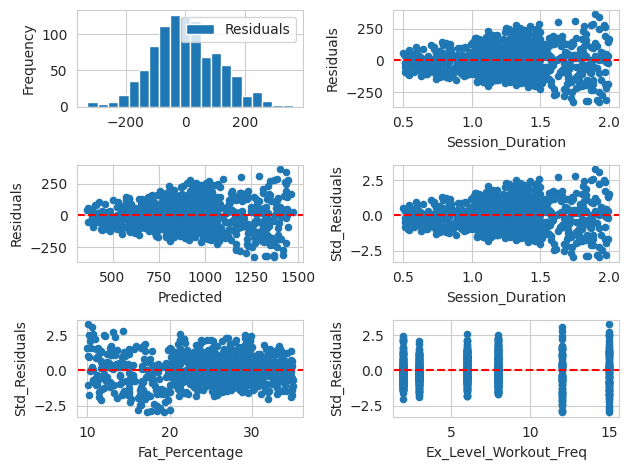

In [182]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Session_Duration", y = "Std_Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Fat_Percentage", y = "Std_Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Ex_Level_Workout_Freq", y = "Std_Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [183]:
formula = "Calories_Burned ~ Session_Duration + Fat_Percentage + Ex_Level_Workout_Freq"
results = cross_validate_model_with_train_test(data, formula, "Calories_Burned")

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 12270.2850, Std = 343.4364
Test_MSE: Mean = 12374.5260, Std = 1359.3641
Train_RMSE: Mean = 110.7603, Std = 1.5594
Test_RMSE: Mean = 111.0791, Std = 5.9960
Train_MAE: Mean = 87.6341, Std = 0.9443
Test_MAE: Mean = 88.0150, Std = 3.6844
Train_R2: Mean = 0.8347, Std = 0.0042
Test_R2: Mean = 0.8330, Std = 0.0159
Train_RSE: Mean = 111.0460, Std = 1.5634
Test_RSE: Mean = 112.2386, Std = 6.0572


In [184]:
residuals = model0.resid
exog = model0.model.exog

white_test = het_white(residuals, exog)
print(f"LM Statistic: {white_test[0]}, p-value: {white_test[1]}")

LM Statistic: 149.11938931245484, p-value: 1.342284485715503e-27


In [185]:
data["Calories_Burned_SQRT"] = np.sqrt(data["Calories_Burned"])

In [186]:
model0 = smf.ols(formula="Calories_Burned_SQRT ~ Session_Duration + Fat_Percentage + Ex_Level_Workout_Freq", data=data).fit()
data["Predicted"] = model0.predict()
print(model0.summary())

                             OLS Regression Results                             
Dep. Variable:     Calories_Burned_SQRT   R-squared:                       0.842
Model:                              OLS   Adj. R-squared:                  0.841
Method:                   Least Squares   F-statistic:                     1716.
Date:                  Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                          15:00:47   Log-Likelihood:                -1970.9
No. Observations:                   973   AIC:                             3950.
Df Residuals:                       969   BIC:                             3969.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept 

In [187]:
data["Residuals"] = data["Calories_Burned_SQRT"] - data["Predicted"]
std_residuals = data["Residuals"].std()
data["Std_Residuals"] = data["Residuals"] / std_residuals
data

,Age,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,...,Workout_Type_Strength,Workout_Type_Yoga,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,Predicted,Residuals,Std_Residuals,Calories_Burned_SQRT
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,...,False,True,False,True,False,False,35.401336,0.834006,0.454442,36.235342
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,...,False,False,False,True,False,False,29.539867,0.175449,0.095600,29.715316
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,...,False,False,True,False,False,False,27.159117,-1.139893,-0.621117,26.019224
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,...,True,False,False,False,False,True,21.447663,1.617462,0.881339,23.065125
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,...,True,False,False,False,False,True,22.056741,1.522911,0.829819,23.579652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,...,True,False,False,False,True,False,34.046072,2.886299,1.572716,36.932371
969,25,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,...,True,False,False,False,True,False,31.847304,3.649175,1.988400,35.496479
970,59,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,...,False,False,True,False,False,False,35.023032,-4.543531,-2.475726,30.479501
971,32,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,...,False,False,False,True,False,False,27.607615,2.107701,1.148466,29.715316


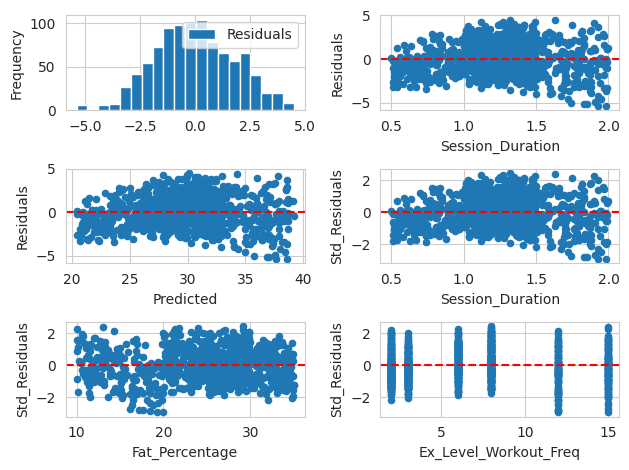

In [188]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Session_Duration", y = "Std_Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Fat_Percentage", y = "Std_Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Ex_Level_Workout_Freq", y = "Std_Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [189]:
formula = "Calories_Burned_SQRT ~ Session_Duration + Fat_Percentage + Ex_Level_Workout_Freq"
results = cross_validate_model_with_train_test(data, formula, "Calories_Burned_SQRT")

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 13113.2824, Std = 388.1576
Test_MSE: Mean = 13214.6342, Std = 1517.4086
Train_RMSE: Mean = 114.5005, Std = 1.7059
Test_RMSE: Mean = 114.7748, Std = 6.4319
Train_MAE: Mean = 90.0172, Std = 1.0209
Test_MAE: Mean = 90.3454, Std = 3.9863
Train_R2: Mean = 0.8234, Std = 0.0048
Test_R2: Mean = 0.8217, Std = 0.0172
Train_RSE: Mean = 114.7959, Std = 1.7102
Test_RSE: Mean = 115.9729, Std = 6.4977


In [190]:
residuals = model0.resid
exog = model0.model.exog

white_test = het_white(residuals, exog)
print(f"LM Statistic: {white_test[0]}, p-value: {white_test[1]}")

LM Statistic: 62.20222872065805, p-value: 5.035375841406902e-10


In [191]:
predictors = ["Session_Duration", "Fat_Percentage", "Ex_Level_Workout_Freq", "Avg_BPM", "Water_Intake"]
X = data[predictors]

X = sm.add_constant(X)  

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data[vif_data["Feature"] != "const"]

print(vif_data)

                 Feature       VIF
1       Session_Duration  2.433541
2         Fat_Percentage  2.665110
3  Ex_Level_Workout_Freq  3.068537
4                Avg_BPM  1.001665
5           Water_Intake  1.559690


In [192]:
model0 = smf.ols(formula="Calories_Burned ~ Session_Duration + Fat_Percentage +  Ex_Level_Workout_Freq + Avg_BPM + Water_Intake", 
                 data=data).fit()
data["Predicted"] = model0.predict()
print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:        Calories_Burned   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     3256.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:00:48   Log-Likelihood:                -5435.1
No. Observations:                 973   AIC:                         1.088e+04
Df Residuals:                     967   BIC:                         1.091e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              -856.93

In [193]:
data["Residuals"] = data["Calories_Burned"] - data["Predicted"]
std_residuals = data["Residuals"].std()
data["Std_Residuals"] = data["Residuals"] / std_residuals
data

,Age,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,...,Workout_Type_Strength,Workout_Type_Yoga,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,Predicted,Residuals,Std_Residuals,Calories_Burned_SQRT
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,...,False,True,False,True,False,False,1342.779120,-29.779120,-0.461311,36.235342
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,...,False,False,False,True,False,False,926.891214,-43.891214,-0.679923,29.715316
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,...,False,False,True,False,False,False,624.228192,52.771808,0.817493,26.019224
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,...,True,False,False,False,False,True,545.352259,-13.352259,-0.206841,23.065125
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,...,True,False,False,False,False,True,568.662794,-12.662794,-0.196160,23.579652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,...,True,False,False,False,True,False,1273.296067,90.703933,1.405102,36.932371
969,25,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,...,True,False,False,False,True,False,1160.147458,99.852542,1.546824,35.496479
970,59,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,...,False,False,True,False,False,False,1074.123184,-145.123184,-2.248116,30.479501
971,32,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,...,False,False,False,True,False,False,781.673953,101.326047,1.569651,29.715316


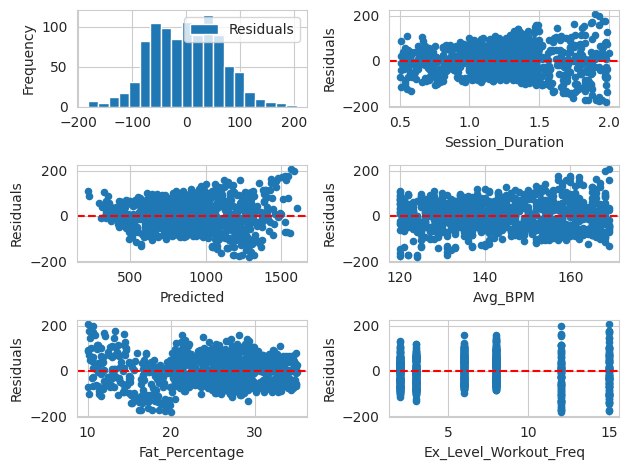

In [194]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data.plot(x = "Ex_Level_Workout_Freq", y = "Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [195]:
formula = "Calories_Burned ~ Session_Duration + Fat_Percentage + Ex_Level_Workout_Freq + Avg_BPM + Water_Intake"
results = cross_validate_model_with_train_test(data, formula, "Calories_Burned")

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 4156.9426, Std = 82.2717
Test_MSE: Mean = 4215.4592, Std = 330.3219
Train_RMSE: Mean = 64.4712, Std = 0.6340
Test_RMSE: Mean = 64.8741, Std = 2.6099
Train_MAE: Mean = 52.9746, Std = 0.5743
Test_MAE: Mean = 53.3299, Std = 1.9097
Train_R2: Mean = 0.9440, Std = 0.0017
Test_R2: Mean = 0.9428, Std = 0.0066
Train_RSE: Mean = 64.7212, Std = 0.6364
Test_RSE: Mean = 65.8979, Std = 2.6497


In [196]:
columns_to_scale = ["Session_Duration", "Fat_Percentage", "Ex_Level_Workout_Freq", "Avg_BPM", "Water_Intake"]
scaled_data = pd.DataFrame(scaler.fit_transform(data.loc[:, columns_to_scale]), columns=columns_to_scale)
scaled_data["Calories_Burned"] = data["Calories_Burned"]
scaled_data["Calories_Burned_SQRT"] = data["Calories_Burned_SQRT"]
scaled_data

,Session_Duration,Fat_Percentage,Ex_Level_Workout_Freq,Avg_BPM,Water_Intake,Calories_Burned,Calories_Burned_SQRT
0,1.264598,-1.978321,1.306226,0.922970,1.455967,1313.0,36.235342
1,0.127098,1.426301,0.342832,0.504494,-0.877898,883.0,29.715316
2,-0.427068,1.346380,0.342832,-1.518142,-0.544488,677.0,26.019224
3,-1.943735,0.611110,-0.861411,1.411193,-0.877898,532.0,23.065125
4,-1.797902,0.675047,-0.861411,0.992716,0.289035,556.0,23.579652
...,...,...,...,...,...,...,...
968,0.914598,-2.393908,1.306226,0.992716,1.455967,1364.0,36.932371
969,0.360432,0.003713,-1.102259,1.550685,0.622444,1260.0,35.496479
970,1.352098,-0.987304,2.028771,-1.657634,0.122330,929.0,30.479501
971,-0.456235,0.515205,-0.138865,0.155764,-0.877898,883.0,29.715316


In [197]:
model0 = smf.ols(formula="Calories_Burned ~ Session_Duration + Fat_Percentage +  Ex_Level_Workout_Freq + Avg_BPM + Water_Intake", 
                 data=scaled_data).fit()
scaled_data["Predicted"] = model0.predict()
print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:        Calories_Burned   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     3256.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:00:50   Log-Likelihood:                -5435.1
No. Observations:                 973   AIC:                         1.088e+04
Df Residuals:                     967   BIC:                         1.091e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               905.42

In [198]:
scaled_data["Residuals"] = scaled_data["Calories_Burned"] - scaled_data["Predicted"]
std_residuals = scaled_data["Residuals"].std()
scaled_data["Std_Residuals"] = scaled_data["Residuals"] / std_residuals
scaled_data

,Session_Duration,Fat_Percentage,Ex_Level_Workout_Freq,Avg_BPM,Water_Intake,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,1.306226,0.922970,1.455967,1313.0,36.235342,1342.779120,-29.779120,-0.461311
1,0.127098,1.426301,0.342832,0.504494,-0.877898,883.0,29.715316,926.891214,-43.891214,-0.679923
2,-0.427068,1.346380,0.342832,-1.518142,-0.544488,677.0,26.019224,624.228192,52.771808,0.817493
3,-1.943735,0.611110,-0.861411,1.411193,-0.877898,532.0,23.065125,545.352259,-13.352259,-0.206841
4,-1.797902,0.675047,-0.861411,0.992716,0.289035,556.0,23.579652,568.662794,-12.662794,-0.196160
...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,1.306226,0.992716,1.455967,1364.0,36.932371,1273.296067,90.703933,1.405102
969,0.360432,0.003713,-1.102259,1.550685,0.622444,1260.0,35.496479,1160.147458,99.852542,1.546824
970,1.352098,-0.987304,2.028771,-1.657634,0.122330,929.0,30.479501,1074.123184,-145.123184,-2.248116
971,-0.456235,0.515205,-0.138865,0.155764,-0.877898,883.0,29.715316,781.673953,101.326047,1.569651


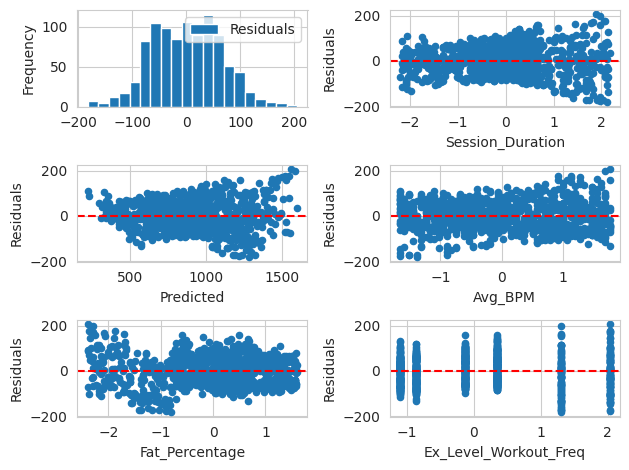

In [199]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
scaled_data.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
scaled_data.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Ex_Level_Workout_Freq", y = "Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [200]:
formula = "Calories_Burned ~ Session_Duration + Fat_Percentage + Ex_Level_Workout_Freq + Avg_BPM + Water_Intake"
results = cross_validate_model_with_train_test(scaled_data, formula, "Calories_Burned")

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 4156.9426, Std = 82.2717
Test_MSE: Mean = 4215.4592, Std = 330.3219
Train_RMSE: Mean = 64.4712, Std = 0.6340
Test_RMSE: Mean = 64.8741, Std = 2.6099
Train_MAE: Mean = 52.9746, Std = 0.5743
Test_MAE: Mean = 53.3299, Std = 1.9097
Train_R2: Mean = 0.9440, Std = 0.0017
Test_R2: Mean = 0.9428, Std = 0.0066
Train_RSE: Mean = 64.7212, Std = 0.6364
Test_RSE: Mean = 65.8979, Std = 2.6497


In [201]:
residuals = model0.resid
exog = model0.model.exog

white_test = het_white(residuals, exog)
print(f"LM Statistic: {white_test[0]}, p-value: {white_test[1]}")

LM Statistic: 207.07959839455015, p-value: 4.451482765804694e-33


In [202]:
model0 = smf.ols(formula="Calories_Burned_SQRT ~ Session_Duration + Fat_Percentage +  Ex_Level_Workout_Freq + Avg_BPM + Water_Intake", 
                 data=scaled_data).fit()
scaled_data["Predicted"] = model0.predict()
print(model0.summary())

                             OLS Regression Results                             
Dep. Variable:     Calories_Burned_SQRT   R-squared:                       0.947
Model:                              OLS   Adj. R-squared:                  0.946
Method:                   Least Squares   F-statistic:                     3423.
Date:                  Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                          15:00:51   Log-Likelihood:                -1442.6
No. Observations:                   973   AIC:                             2897.
Df Residuals:                       967   BIC:                             2926.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept 

In [203]:
scaled_data["Residuals"] = scaled_data["Calories_Burned_SQRT"] - scaled_data["Predicted"]
std_residuals = scaled_data["Residuals"].std()
data["Std_Residuals"] = scaled_data["Residuals"] / std_residuals
scaled_data

,Session_Duration,Fat_Percentage,Ex_Level_Workout_Freq,Avg_BPM,Water_Intake,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,1.306226,0.922970,1.455967,1313.0,36.235342,36.830519,-0.595177,-0.461311
1,0.127098,1.426301,0.342832,0.504494,-0.877898,883.0,29.715316,30.404635,-0.689319,-0.679923
2,-0.427068,1.346380,0.342832,-1.518142,-0.544488,677.0,26.019224,25.209929,0.809295,0.817493
3,-1.943735,0.611110,-0.861411,1.411193,-0.877898,532.0,23.065125,23.366099,-0.300974,-0.206841
4,-1.797902,0.675047,-0.861411,0.992716,0.289035,556.0,23.579652,23.830238,-0.250586,-0.196160
...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,1.306226,0.992716,1.455967,1364.0,36.932371,35.477468,1.454902,1.405102
969,0.360432,0.003713,-1.102259,1.550685,0.622444,1260.0,35.496479,34.174246,1.322233,1.546824
970,1.352098,-0.987304,2.028771,-1.657634,0.122330,929.0,30.479501,32.548864,-2.069363,-2.248116
971,-0.456235,0.515205,-0.138865,0.155764,-0.877898,883.0,29.715316,27.658185,2.057131,1.569651


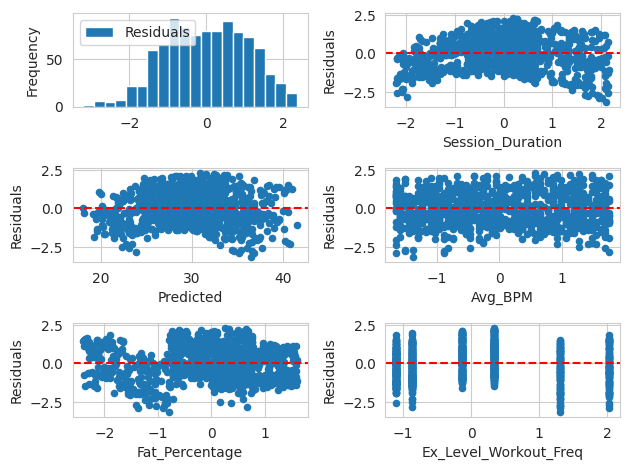

In [204]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
scaled_data.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
scaled_data.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
scaled_data.plot(x = "Ex_Level_Workout_Freq", y = "Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [205]:
formula = "Calories_Burned_SQRT ~ Session_Duration + Fat_Percentage + Ex_Level_Workout_Freq + Avg_BPM + Water_Intake"
results = cross_validate_model_with_train_test(scaled_data, formula, "Calories_Burned_SQRT")

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 4309.1710, Std = 62.9986
Test_MSE: Mean = 4364.6130, Std = 325.8664
Train_RMSE: Mean = 65.6425, Std = 0.4806
Test_RMSE: Mean = 66.0190, Std = 2.4715
Train_MAE: Mean = 53.6938, Std = 0.4925
Test_MAE: Mean = 53.9732, Std = 1.9214
Train_R2: Mean = 0.9419, Std = 0.0015
Test_R2: Mean = 0.9408, Std = 0.0065
Train_RSE: Mean = 65.8970, Std = 0.4825
Test_RSE: Mean = 67.0609, Std = 2.5102


In [206]:
residuals = model0.resid
exog = model0.model.exog

white_test = het_white(residuals, exog)
print(f"LM Statistic: {white_test[0]}, p-value: {white_test[1]}")

LM Statistic: 172.93091897478232, p-value: 2.3305077059653726e-26


In [209]:
columns = [
    "Session_Duration", "Fat_Percentage", "Avg_BPM", "Water_Intake", "Age", "BMI", "BMI_Label_Normal_weight", "BMI_Label_Obese",
    "BMI_Label_Overweight", "BMI_Label_Underweight",
    "Max_BPM", "Resting_BPM", "Workout_Type_Cardio", "Workout_Type_HIIT", "Workout_Type_Strength", "Workout_Type_Yoga",
    "Gender_Female", "Gender_Male", "Weight", "Height", 
    "Experience_Level", "Workout_Frequency", "HRR", "VO2_Max", "Fat_In_Kg", 
    "Water_Intake_Session_Duration", "Ex_Level_Workout_Freq", 
    "Session_Duration_Workout_Frequency"
]

X = data[columns]
Y = data["Calories_Burned"]

max_degree = 8 

for col in ["Session_Duration", "Fat_Percentage", "Avg_BPM", "Water_Intake"]:
    for degree in range(2, max_degree + 1):
        X[f"{col}_{degree}"] = X[col] ** degree

data_pom = pd.concat([X, Y], axis=1)

exclude_from_scaling = ["Gender", "Experience_Level", "BMI_Label", "Workout_Frequency", "Ex_Level_Workout_Freq", "Workout_Type"]
columns_to_scale = [col for col in X.columns if col not in exclude_from_scaling]

scaler = StandardScaler()
data_pom[columns_to_scale] = scaler.fit_transform(data_pom[columns_to_scale])

vars = set(X.columns)
pvalue_threshold = 0.01
highest_pvalue = 0.10
intercept = True

while (len(vars) > 0) and (highest_pvalue > pvalue_threshold):
    formula = "Calories_Burned ~ {}".format(" + ".join(vars)) 
    if not intercept:
        formula += " - 1"
    test_model = smf.ols(formula, data_pom).fit()
    pvalues = test_model.pvalues
    highest_pvalue = max(pvalues)
    if highest_pvalue > pvalue_threshold:
        if pvalues.idxmax() == "Intercept":
            intercept = False
        else:
            vars.remove(pvalues.idxmax())

print("Selected variables:", vars)

X = data_pom[list(vars)]
X = sm.add_constant(X)

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data[vif_data["Feature"] != "const"]

print("VIF:")
print(vif_data)


Selected variables: {'Session_Duration_4', 'Session_Duration', 'Fat_Percentage', 'Fat_Percentage_4', 'Gender_Female', 'Session_Duration_2', 'Fat_Percentage_6', 'BMI_Label_Obese', 'Session_Duration_3', 'Avg_BPM_5', 'Age', 'Fat_Percentage_5', 'Session_Duration_5', 'Avg_BPM_4'}
VIF:
               Feature           VIF
1   Session_Duration_4  8.411817e+06
2     Session_Duration  1.820022e+05
3       Fat_Percentage  5.259922e+02
4     Fat_Percentage_4  1.097213e+05
5        Gender_Female  1.887321e+00
6   Session_Duration_2  3.841660e+06
7     Fat_Percentage_6  7.020441e+04
8      BMI_Label_Obese  1.154982e+00
9   Session_Duration_3  1.246063e+07
10           Avg_BPM_5  5.831451e+02
11                 Age  1.010059e+00
12    Fat_Percentage_5  3.287115e+05
13  Session_Duration_5  8.182233e+05
14           Avg_BPM_4  5.834757e+02


In [210]:
data_pom["Calories_Burned_SQRT"] = data["Calories_Burned_SQRT"]

In [211]:
data_pom

,Session_Duration,Fat_Percentage,Avg_BPM,Water_Intake,Age,BMI,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,...,Avg_BPM_8,Water_Intake_2,Water_Intake_3,Water_Intake_4,Water_Intake_5,Water_Intake_6,Water_Intake_7,Water_Intake_8,Calories_Burned,Calories_Burned_SQRT
0,1.264598,-1.978321,0.922970,1.455967,1.422343,0.794278,-0.783325,2.016856,-0.576955,-0.456832,...,0.752238,1.561316,1.642463,1.701594,1.742226,1.767898,1.781598,1.785650,1313.0,36.235342
1,0.127098,1.426301,0.504494,-0.877898,0.600965,1.064652,-0.783325,2.016856,-0.576955,-0.456832,...,0.191455,-0.891223,-0.878212,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316
2,-0.427068,1.346380,-1.518142,-0.544488,-0.548964,-0.030361,1.276609,-0.495821,-0.576955,-0.456832,...,-1.063273,-0.615938,-0.660295,-0.681942,-0.686735,-0.680204,-0.666765,-0.649598,677.0,26.019224
3,-1.943735,0.611110,1.411193,-0.877898,-1.123928,-0.976669,-0.783325,-0.495821,-0.576955,2.188988,...,1.626646,-0.891223,-0.878212,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,532.0,23.065125
4,-1.797902,0.675047,0.992716,0.289035,-0.056137,-1.580503,-0.783325,-0.495821,-0.576955,2.188988,...,0.861342,0.181763,0.073471,-0.028228,-0.118884,-0.196654,-0.261423,-0.314050,556.0,23.579652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,0.992716,1.455967,-1.206066,0.579482,-0.783325,-0.495821,1.733238,-0.456832,...,0.861342,1.561316,1.642463,1.701594,1.742226,1.767898,1.781598,1.785650,1364.0,36.932371
969,0.360432,0.003713,1.550685,0.622444,-1.123928,0.116842,-0.783325,-0.495821,1.733238,-0.456832,...,1.928902,0.544638,0.452015,0.353174,0.254778,0.161255,0.075170,-0.002247,1260.0,35.496479
970,1.352098,-0.987304,-1.657634,0.122330,1.668756,-0.812942,1.276609,-0.495821,-0.576955,-0.456832,...,-1.097754,0.009709,-0.096678,-0.190702,-0.269699,-0.333483,-0.383272,-0.420905,929.0,30.479501
971,-0.456235,0.515205,0.155764,-0.877898,-0.548964,1.926843,-0.783325,2.016856,-0.576955,-0.456832,...,-0.170591,-0.891223,-0.878212,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316


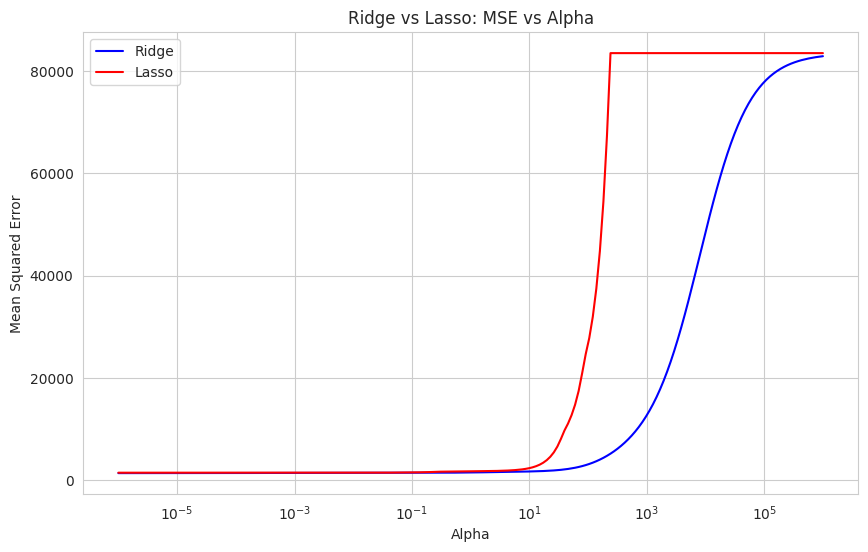

In [212]:
selected_variables = {'Session_Duration_4', 'Session_Duration', 'Fat_Percentage', 'Fat_Percentage_4', 'Gender_Female', 'Session_Duration_2', 
                      'Fat_Percentage_6', 'BMI_Label_Obese', 'Session_Duration_3', 'Avg_BPM_5', 'Age', 'Fat_Percentage_5', 'Session_Duration_5', 'Avg_BPM_4'}

X = data_pom[list(selected_variables)]
y = data_pom['Calories_Burned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = np.logspace(-6, 6, 200)

ridge_mse = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    ridge_mse.append(mse)

lasso_mse = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    lasso_mse.append(mse)

plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_mse, label='Ridge', color='blue')
plt.plot(alphas, lasso_mse, label='Lasso', color='red')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Ridge vs Lasso: MSE vs Alpha')
plt.legend()
plt.grid(True)
plt.show()

In [213]:
lasso = Lasso(alpha=8).fit(X, y)
coefficients = lasso.coef_

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

non_zero_features = coef_df[coef_df['Coefficient'] != 0]

print(non_zero_features)

             Feature  Coefficient
2      Gender_Female   -35.159471
8   Session_Duration   236.688145
10               Age   -32.825860
11         Avg_BPM_4    80.691090
13    Fat_Percentage    -2.372441


In [214]:
data_pom["Predicted"] = lasso.predict(X)
data_pom["Residuals"] = data_pom["Calories_Burned"] - data_pom["Predicted"]
std_residuals = data_pom["Residuals"].std()
data_pom["Std_Residuals"] = data_pom["Residuals"] / std_residuals
data_pom

,Session_Duration,Fat_Percentage,Avg_BPM,Water_Intake,Age,BMI,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,...,Water_Intake_4,Water_Intake_5,Water_Intake_6,Water_Intake_7,Water_Intake_8,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,0.922970,1.455967,1.422343,0.794278,-0.783325,2.016856,-0.576955,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1313.0,36.235342,1266.604704,46.395296,1.040093
1,0.127098,1.426301,0.504494,-0.877898,0.600965,1.064652,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,905.914968,-22.914968,-0.513709
2,-0.427068,1.346380,-1.518142,-0.544488,-0.548964,-0.030361,1.276609,-0.495821,-0.576955,-0.456832,...,-0.681942,-0.686735,-0.680204,-0.666765,-0.649598,677.0,26.019224,676.814549,0.185451,0.004157
3,-1.943735,0.611110,1.411193,-0.877898,-1.123928,-0.976669,-0.783325,-0.495821,-0.576955,2.188988,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,532.0,23.065125,637.416935,-105.416935,-2.363244
4,-1.797902,0.675047,0.992716,0.289035,-0.056137,-1.580503,-0.783325,-0.495821,-0.576955,2.188988,...,-0.028228,-0.118884,-0.196654,-0.261423,-0.314050,556.0,23.579652,591.101911,-35.101911,-0.786917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,0.992716,1.455967,-1.206066,0.579482,-0.783325,-0.495821,1.733238,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1364.0,36.932371,1278.146790,85.853210,1.924663
969,0.360432,0.003713,1.550685,0.622444,-1.123928,0.116842,-0.783325,-0.495821,1.733238,-0.456832,...,0.353174,0.254778,0.161255,0.075170,-0.002247,1260.0,35.496479,1200.593553,59.406447,1.331778
970,1.352098,-0.987304,-1.657634,0.122330,1.668756,-0.812942,1.276609,-0.495821,-0.576955,-0.456832,...,-0.190702,-0.269699,-0.333483,-0.383272,-0.420905,929.0,30.479501,1024.205412,-95.205412,-2.134321
971,-0.456235,0.515205,0.155764,-0.877898,-0.548964,1.926843,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,848.328433,34.671567,0.777270


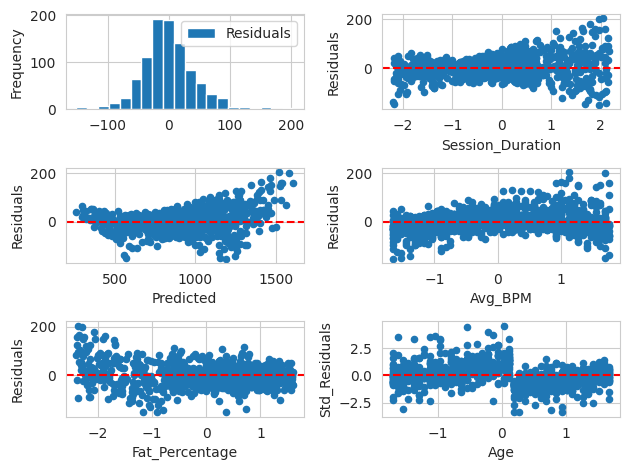

In [215]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data_pom.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data_pom.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Age", y = "Std_Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [216]:
results = cross_validate_model_with_train_test_regularization(X, lasso, y)

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 1984.0953, Std = 24.7073
Test_MSE: Mean = 2024.6023, Std = 139.0322
Train_RMSE: Mean = 44.5423, Std = 0.2778
Test_RMSE: Mean = 44.9685, Std = 1.5614
Train_MAE: Mean = 32.6570, Std = 0.2421
Test_MAE: Mean = 33.0028, Std = 0.9309
Train_R2: Mean = 0.9733, Std = 0.0005
Test_R2: Mean = 0.9727, Std = 0.0018
Train_RSE: Mean = 44.9778, Std = 0.2805
Test_RSE: Mean = 46.8087, Std = 1.6246


In [217]:
ridge = Ridge(alpha=10).fit(X, y)
coefficients = ridge.coef_

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

non_zero_features = coef_df[coef_df['Coefficient'] != 0]

print(non_zero_features)

               Feature  Coefficient
0     Fat_Percentage_4    15.403310
1     Fat_Percentage_6    -5.253002
2        Gender_Female   -43.249837
3     Fat_Percentage_5     6.201054
4   Session_Duration_5   -28.006131
5   Session_Duration_4   -11.221615
6      BMI_Label_Obese     3.765137
7   Session_Duration_3    23.658378
8     Session_Duration   171.463418
9            Avg_BPM_5    16.490353
10                 Age   -40.512640
11           Avg_BPM_4    71.494382
12  Session_Duration_2    83.265656
13      Fat_Percentage   -17.346602


In [218]:
data_pom["Predicted"] = ridge.predict(X)
data_pom["Residuals"] = data_pom["Calories_Burned"] - data_pom["Predicted"]
std_residuals = data_pom["Residuals"].std()
data_pom["Std_Residuals"] = data_pom["Residuals"] / std_residuals
data_pom

,Session_Duration,Fat_Percentage,Avg_BPM,Water_Intake,Age,BMI,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,...,Water_Intake_4,Water_Intake_5,Water_Intake_6,Water_Intake_7,Water_Intake_8,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,0.922970,1.455967,1.422343,0.794278,-0.783325,2.016856,-0.576955,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1313.0,36.235342,1297.165865,15.834135,0.379084
1,0.127098,1.426301,0.504494,-0.877898,0.600965,1.064652,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,912.846747,-29.846747,-0.714560
2,-0.427068,1.346380,-1.518142,-0.544488,-0.548964,-0.030361,1.276609,-0.495821,-0.576955,-0.456832,...,-0.681942,-0.686735,-0.680204,-0.666765,-0.649598,677.0,26.019224,665.081008,11.918992,0.285352
3,-1.943735,0.611110,1.411193,-0.877898,-1.123928,-0.976669,-0.783325,-0.495821,-0.576955,2.188988,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,532.0,23.065125,665.319261,-133.319261,-3.191790
4,-1.797902,0.675047,0.992716,0.289035,-0.056137,-1.580503,-0.783325,-0.495821,-0.576955,2.188988,...,-0.028228,-0.118884,-0.196654,-0.261423,-0.314050,556.0,23.579652,603.296905,-47.296905,-1.132333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,0.992716,1.455967,-1.206066,0.579482,-0.783325,-0.495821,1.733238,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1364.0,36.932371,1322.508335,41.491665,0.993350
969,0.360432,0.003713,1.550685,0.622444,-1.123928,0.116842,-0.783325,-0.495821,1.733238,-0.456832,...,0.353174,0.254778,0.161255,0.075170,-0.002247,1260.0,35.496479,1224.760031,35.239969,0.843678
970,1.352098,-0.987304,-1.657634,0.122330,1.668756,-0.812942,1.276609,-0.495821,-0.576955,-0.456832,...,-0.190702,-0.269699,-0.333483,-0.383272,-0.420905,929.0,30.479501,1002.566362,-73.566362,-1.761249
971,-0.456235,0.515205,0.155764,-0.877898,-0.548964,1.926843,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,856.949817,26.050183,0.623666


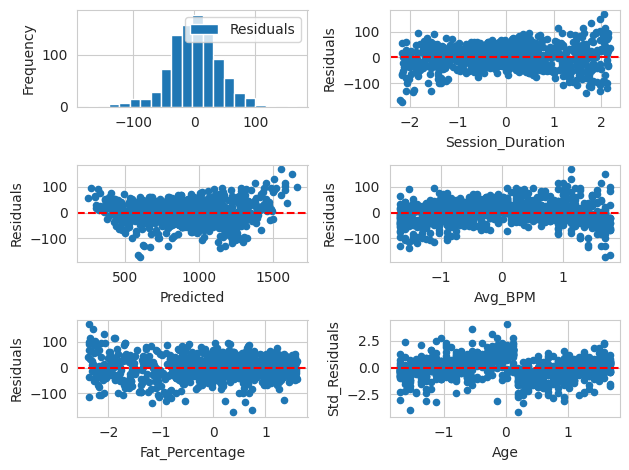

In [219]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data_pom.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data_pom.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Age", y = "Std_Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [220]:
results = cross_validate_model_with_train_test_regularization(X, ridge, y)

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 1756.5573, Std = 33.9577
Test_MSE: Mean = 1817.2674, Std = 153.3655
Train_RMSE: Mean = 41.9093, Std = 0.4054
Test_RMSE: Mean = 42.5923, Std = 1.7796
Train_MAE: Mean = 31.8337, Std = 0.3224
Test_MAE: Mean = 32.2585, Std = 1.6930
Train_R2: Mean = 0.9763, Std = 0.0007
Test_R2: Mean = 0.9754, Std = 0.0023
Train_RSE: Mean = 42.3191, Std = 0.4094
Test_RSE: Mean = 44.3353, Std = 1.8537


In [221]:
y = data_pom['Calories_Burned_SQRT']

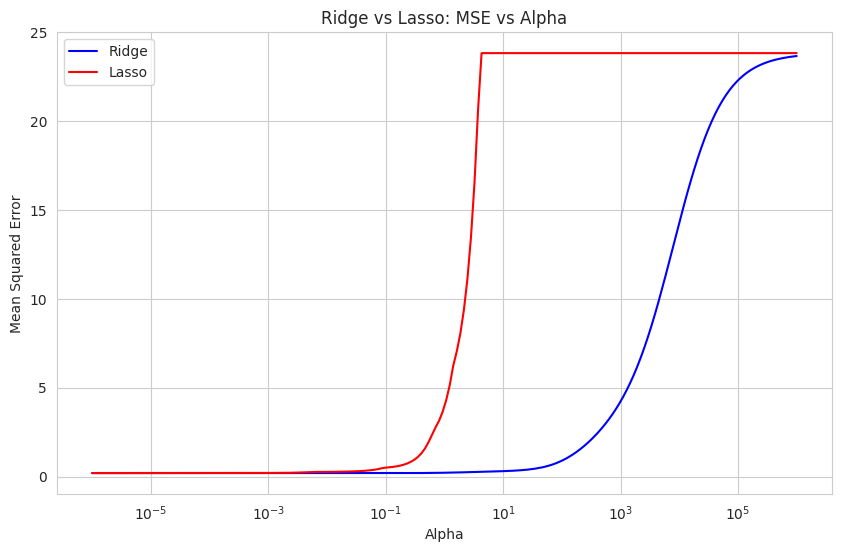

In [222]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = np.logspace(-6, 6, 200)

ridge_mse = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    ridge_mse.append(mse)

lasso_mse = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    lasso_mse.append(mse)

plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_mse, label='Ridge', color='blue')
plt.plot(alphas, lasso_mse, label='Lasso', color='red')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Ridge vs Lasso: MSE vs Alpha')
plt.legend()
plt.grid(True)
plt.show()

In [223]:
lasso = Lasso(alpha=0.01).fit(X, y)
coefficients = lasso.coef_

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

non_zero_features = coef_df[coef_df['Coefficient'] != 0]

print(non_zero_features)

               Feature  Coefficient
1     Fat_Percentage_6     0.019478
2        Gender_Female    -0.703937
5   Session_Duration_4    -0.773701
6      BMI_Label_Obese     0.038403
8     Session_Duration     4.890646
10                 Age    -0.655862
11           Avg_BPM_4     1.441619


In [224]:
data_pom["Predicted"] = lasso.predict(X)
data_pom["Residuals"] = data_pom["Calories_Burned_SQRT"] - data_pom["Predicted"]
std_residuals = data_pom["Residuals"].std()
data_pom["Std_Residuals"] = data_pom["Residuals"] / std_residuals
data_pom

,Session_Duration,Fat_Percentage,Avg_BPM,Water_Intake,Age,BMI,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,...,Water_Intake_4,Water_Intake_5,Water_Intake_6,Water_Intake_7,Water_Intake_8,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,0.922970,1.455967,1.422343,0.794278,-0.783325,2.016856,-0.576955,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1313.0,36.235342,36.008865,0.226477,0.408799
1,0.127098,1.426301,0.504494,-0.877898,0.600965,1.064652,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,30.059025,-0.343709,-0.620407
2,-0.427068,1.346380,-1.518142,-0.544488,-0.548964,-0.030361,1.276609,-0.495821,-0.576955,-0.456832,...,-0.681942,-0.686735,-0.680204,-0.666765,-0.649598,677.0,26.019224,25.859454,0.159769,0.288389
3,-1.943735,0.611110,1.411193,-0.877898,-1.123928,-0.976669,-0.783325,-0.495821,-0.576955,2.188988,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,532.0,23.065125,24.575686,-1.510560,-2.726616
4,-1.797902,0.675047,0.992716,0.289035,-0.056137,-1.580503,-0.783325,-0.495821,-0.576955,2.188988,...,-0.028228,-0.118884,-0.196654,-0.261423,-0.314050,556.0,23.579652,23.765518,-0.185865,-0.335494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,0.992716,1.455967,-1.206066,0.579482,-0.783325,-0.495821,1.733238,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1364.0,36.932371,36.496443,0.435928,0.786865
969,0.360432,0.003713,1.550685,0.622444,-1.123928,0.116842,-0.783325,-0.495821,1.733238,-0.456832,...,0.353174,0.254778,0.161255,0.075170,-0.002247,1260.0,35.496479,35.373762,0.122717,0.221508
970,1.352098,-0.987304,-1.657634,0.122330,1.668756,-0.812942,1.276609,-0.495821,-0.576955,-0.456832,...,-0.190702,-0.269699,-0.333483,-0.383272,-0.420905,929.0,30.479501,31.387346,-0.907845,-1.638692
971,-0.456235,0.515205,0.155764,-0.877898,-0.548964,1.926843,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,29.091142,0.624174,1.126657


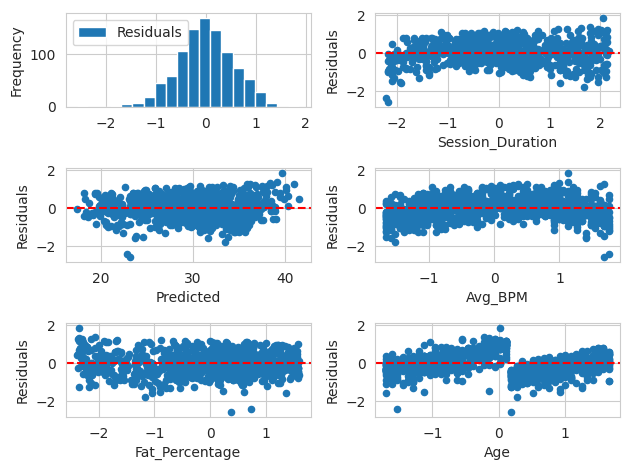

In [225]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data_pom.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data_pom.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Age", y = "Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [226]:
results = cross_validate_model_with_train_test_regularization(X, lasso, y)

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 1158.5616, Std = 30.9667
Test_MSE: Mean = 1185.9632, Std = 109.8581
Train_RMSE: Mean = 34.0346, Std = 0.4548
Test_RMSE: Mean = 34.4008, Std = 1.5969
Train_MAE: Mean = 26.1219, Std = 0.3330
Test_MAE: Mean = 26.4005, Std = 1.3004
Train_R2: Mean = 0.9844, Std = 0.0006
Test_R2: Mean = 0.9839, Std = 0.0020
Train_RSE: Mean = 34.3674, Std = 0.4593
Test_RSE: Mean = 35.8086, Std = 1.6645


In [227]:
ridge = Ridge(alpha=15).fit(X, y)
coefficients = ridge.coef_

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

non_zero_features = coef_df[coef_df['Coefficient'] != 0]

print(non_zero_features)

               Feature  Coefficient
0     Fat_Percentage_4     0.098445
1     Fat_Percentage_6    -0.044403
2        Gender_Female    -0.716212
3     Fat_Percentage_5     0.029057
4   Session_Duration_5    -0.760353
5   Session_Duration_4    -0.441050
6      BMI_Label_Obese     0.049132
7   Session_Duration_3     0.262151
8     Session_Duration     3.470447
9            Avg_BPM_5     0.375259
10                 Age    -0.652068
11           Avg_BPM_4     1.063935
12  Session_Duration_2     1.524270
13      Fat_Percentage    -0.024645


In [229]:
data_pom["Predicted"] = ridge.predict(X)
data_pom["Residuals"] = data_pom["Calories_Burned_SQRT"] - data_pom["Predicted"]
std_residuals = data_pom["Residuals"].std()
data_pom["Std_Residuals"] = data_pom["Residuals"] / std_residuals
data_pom

,Session_Duration,Fat_Percentage,Avg_BPM,Water_Intake,Age,BMI,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,...,Water_Intake_4,Water_Intake_5,Water_Intake_6,Water_Intake_7,Water_Intake_8,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,0.922970,1.455967,1.422343,0.794278,-0.783325,2.016856,-0.576955,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1313.0,36.235342,36.088991,0.146351,0.243107
1,0.127098,1.426301,0.504494,-0.877898,0.600965,1.064652,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,30.054859,-0.339543,-0.564023
2,-0.427068,1.346380,-1.518142,-0.544488,-0.548964,-0.030361,1.276609,-0.495821,-0.576955,-0.456832,...,-0.681942,-0.686735,-0.680204,-0.666765,-0.649598,677.0,26.019224,25.833615,0.185609,0.308320
3,-1.943735,0.611110,1.411193,-0.877898,-1.123928,-0.976669,-0.783325,-0.495821,-0.576955,2.188988,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,532.0,23.065125,24.994607,-1.929482,-3.205108
4,-1.797902,0.675047,0.992716,0.289035,-0.056137,-1.580503,-0.783325,-0.495821,-0.576955,2.188988,...,-0.028228,-0.118884,-0.196654,-0.261423,-0.314050,556.0,23.579652,24.083665,-0.504013,-0.837229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,0.992716,1.455967,-1.206066,0.579482,-0.783325,-0.495821,1.733238,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1364.0,36.932371,36.497704,0.434666,0.722034
969,0.360432,0.003713,1.550685,0.622444,-1.123928,0.116842,-0.783325,-0.495821,1.733238,-0.456832,...,0.353174,0.254778,0.161255,0.075170,-0.002247,1260.0,35.496479,35.328585,0.167894,0.278893
970,1.352098,-0.987304,-1.657634,0.122330,1.668756,-0.812942,1.276609,-0.495821,-0.576955,-0.456832,...,-0.190702,-0.269699,-0.333483,-0.383272,-0.420905,929.0,30.479501,31.469789,-0.990288,-1.644991
971,-0.456235,0.515205,0.155764,-0.877898,-0.548964,1.926843,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,29.008656,0.706660,1.173849


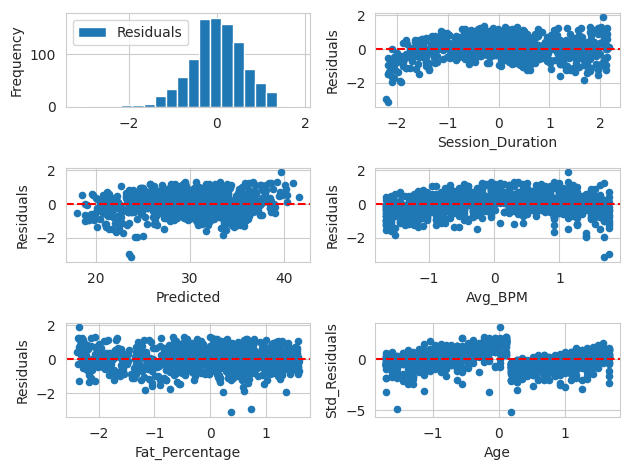

In [230]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data_pom.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data_pom.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Age", y = "Std_Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [231]:
results = cross_validate_model_with_train_test_regularization(X, ridge, y)

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 1325.4243, Std = 38.8513
Test_MSE: Mean = 1361.0907, Std = 122.4174
Train_RMSE: Mean = 36.4025, Std = 0.5339
Test_RMSE: Mean = 36.8561, Std = 1.6491
Train_MAE: Mean = 28.0413, Std = 0.4008
Test_MAE: Mean = 28.3728, Std = 1.3686
Train_R2: Mean = 0.9821, Std = 0.0007
Test_R2: Mean = 0.9815, Std = 0.0022
Train_RSE: Mean = 36.7584, Std = 0.5392
Test_RSE: Mean = 38.3644, Std = 1.7192


In [232]:
data_pom.columns

Index(['Session_Duration', 'Fat_Percentage', 'Avg_BPM', 'Water_Intake', 'Age',
       'BMI', 'BMI_Label_Normal_weight', 'BMI_Label_Obese',
       'BMI_Label_Overweight', 'BMI_Label_Underweight', 'Max_BPM',
       'Resting_BPM', 'Workout_Type_Cardio', 'Workout_Type_HIIT',
       'Workout_Type_Strength', 'Workout_Type_Yoga', 'Gender_Female',
       'Gender_Male', 'Weight', 'Height', 'Experience_Level',
       'Workout_Frequency', 'HRR', 'VO2_Max', 'Fat_In_Kg',
       'Water_Intake_Session_Duration', 'Ex_Level_Workout_Freq',
       'Session_Duration_Workout_Frequency', 'Session_Duration_2',
       'Session_Duration_3', 'Session_Duration_4', 'Session_Duration_5',
       'Session_Duration_6', 'Session_Duration_7', 'Session_Duration_8',
       'Fat_Percentage_2', 'Fat_Percentage_3', 'Fat_Percentage_4',
       'Fat_Percentage_5', 'Fat_Percentage_6', 'Fat_Percentage_7',
       'Fat_Percentage_8', 'Avg_BPM_2', 'Avg_BPM_3', 'Avg_BPM_4', 'Avg_BPM_5',
       'Avg_BPM_6', 'Avg_BPM_7', 'Avg_BPM_8', 

In [233]:
predictors = ["Session_Duration", "Fat_Percentage", "Ex_Level_Workout_Freq", "Avg_BPM", "Water_Intake", "Age"]
X = data_pom[predictors]

X = sm.add_constant(X)  

vif_data = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data[vif_data["Feature"] != "const"]

print(vif_data)

                 Feature       VIF
1       Session_Duration  2.434704
2         Fat_Percentage  2.666366
3  Ex_Level_Workout_Freq  3.068952
4                Avg_BPM  1.003051
5           Water_Intake  1.564004
6                    Age  1.004657


In [234]:
model0 = smf.ols(formula="Calories_Burned ~ Session_Duration * Water_Intake + Fat_Percentage + Ex_Level_Workout_Freq + Avg_BPM + Age", 
                 data=data_pom).fit()
data_pom["Predicted"] = model0.predict()
print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:        Calories_Burned   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     4247.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:06:08   Log-Likelihood:                -5153.7
No. Observations:                 973   AIC:                         1.032e+04
Df Residuals:                     965   BIC:                         1.036e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [235]:
data_pom["Residuals"] = data_pom["Calories_Burned"] - data_pom["Predicted"]
std_residuals = data_pom["Residuals"].std()
data_pom["Std_Residuals"] = data_pom["Residuals"] / std_residuals
data_pom

,Session_Duration,Fat_Percentage,Avg_BPM,Water_Intake,Age,BMI,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,...,Water_Intake_4,Water_Intake_5,Water_Intake_6,Water_Intake_7,Water_Intake_8,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,0.922970,1.455967,1.422343,0.794278,-0.783325,2.016856,-0.576955,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1313.0,36.235342,1296.034801,16.965199,0.350934
1,0.127098,1.426301,0.504494,-0.877898,0.600965,1.064652,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,901.672749,-18.672749,-0.386255
2,-0.427068,1.346380,-1.518142,-0.544488,-0.548964,-0.030361,1.276609,-0.495821,-0.576955,-0.456832,...,-0.681942,-0.686735,-0.680204,-0.666765,-0.649598,677.0,26.019224,648.598769,28.401231,0.587494
3,-1.943735,0.611110,1.411193,-0.877898,-1.123928,-0.976669,-0.783325,-0.495821,-0.576955,2.188988,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,532.0,23.065125,611.535478,-79.535478,-1.645231
4,-1.797902,0.675047,0.992716,0.289035,-0.056137,-1.580503,-0.783325,-0.495821,-0.576955,2.188988,...,-0.028228,-0.118884,-0.196654,-0.261423,-0.314050,556.0,23.579652,572.032284,-16.032284,-0.331636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,0.992716,1.455967,-1.206066,0.579482,-0.783325,-0.495821,1.733238,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1364.0,36.932371,1327.399040,36.600960,0.757109
969,0.360432,0.003713,1.550685,0.622444,-1.123928,0.116842,-0.783325,-0.495821,1.733238,-0.456832,...,0.353174,0.254778,0.161255,0.075170,-0.002247,1260.0,35.496479,1212.666530,47.333470,0.979117
970,1.352098,-0.987304,-1.657634,0.122330,1.668756,-0.812942,1.276609,-0.495821,-0.576955,-0.456832,...,-0.190702,-0.269699,-0.333483,-0.383272,-0.420905,929.0,30.479501,992.406875,-63.406875,-1.311603
971,-0.456235,0.515205,0.155764,-0.877898,-0.548964,1.926843,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,804.882824,78.117176,1.615893


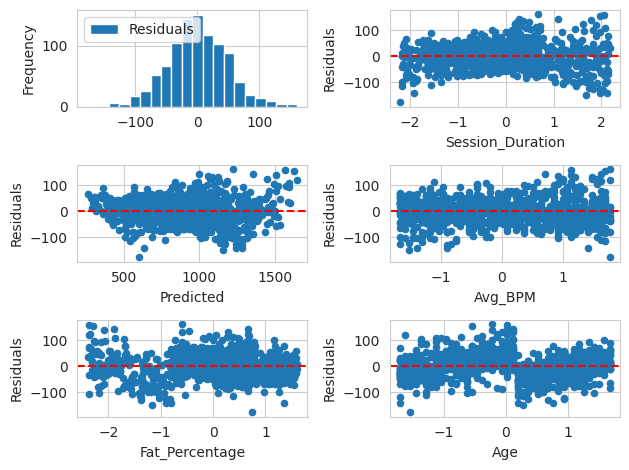

In [236]:
fig, ((g1, g2), (g3, g4), (g5, g6)) = plt.subplots(3,2)
data_pom.plot(y = "Residuals", kind = "hist", bins = 20, ax = g1)
data_pom.plot(x = "Session_Duration", y = "Residuals", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Predicted", y = "Residuals", kind = "scatter", ax = g3)
g3.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Avg_BPM", y = "Residuals", kind = "scatter", ax = g4)
g4.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Fat_Percentage", y = "Residuals", kind = "scatter", ax = g5)
g5.axhline(y = 0, c = "red", linestyle = "dashed")
data_pom.plot(x = "Age", y = "Residuals", kind = "scatter", ax = g6)
g6.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

In [237]:
formula = "Calories_Burned ~ Session_Duration * Water_Intake + Fat_Percentage + Ex_Level_Workout_Freq + Avg_BPM + Age"
results = cross_validate_model_with_train_test(data_pom, formula, "Calories_Burned")

for metric, (mean, std) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, Std = {std:.4f}")

Train_MSE: Mean = 2328.1116, Std = 41.3079
Test_MSE: Mean = 2394.2075, Std = 147.3888
Train_RMSE: Mean = 48.2486, Std = 0.4291
Test_RMSE: Mean = 48.9079, Std = 1.4923
Train_MAE: Mean = 37.4741, Std = 0.3495
Test_MAE: Mean = 38.0073, Std = 0.8455
Train_R2: Mean = 0.9686, Std = 0.0010
Test_R2: Mean = 0.9675, Std = 0.0036
Train_RSE: Mean = 48.4985, Std = 0.4313
Test_RSE: Mean = 49.9453, Std = 1.5231


In [238]:
data_pom

,Session_Duration,Fat_Percentage,Avg_BPM,Water_Intake,Age,BMI,BMI_Label_Normal_weight,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,...,Water_Intake_4,Water_Intake_5,Water_Intake_6,Water_Intake_7,Water_Intake_8,Calories_Burned,Calories_Burned_SQRT,Predicted,Residuals,Std_Residuals
0,1.264598,-1.978321,0.922970,1.455967,1.422343,0.794278,-0.783325,2.016856,-0.576955,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1313.0,36.235342,1296.034801,16.965199,0.350934
1,0.127098,1.426301,0.504494,-0.877898,0.600965,1.064652,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,901.672749,-18.672749,-0.386255
2,-0.427068,1.346380,-1.518142,-0.544488,-0.548964,-0.030361,1.276609,-0.495821,-0.576955,-0.456832,...,-0.681942,-0.686735,-0.680204,-0.666765,-0.649598,677.0,26.019224,648.598769,28.401231,0.587494
3,-1.943735,0.611110,1.411193,-0.877898,-1.123928,-0.976669,-0.783325,-0.495821,-0.576955,2.188988,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,532.0,23.065125,611.535478,-79.535478,-1.645231
4,-1.797902,0.675047,0.992716,0.289035,-0.056137,-1.580503,-0.783325,-0.495821,-0.576955,2.188988,...,-0.028228,-0.118884,-0.196654,-0.261423,-0.314050,556.0,23.579652,572.032284,-16.032284,-0.331636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,0.914598,-2.393908,0.992716,1.455967,-1.206066,0.579482,-0.783325,-0.495821,1.733238,-0.456832,...,1.701594,1.742226,1.767898,1.781598,1.785650,1364.0,36.932371,1327.399040,36.600960,0.757109
969,0.360432,0.003713,1.550685,0.622444,-1.123928,0.116842,-0.783325,-0.495821,1.733238,-0.456832,...,0.353174,0.254778,0.161255,0.075170,-0.002247,1260.0,35.496479,1212.666530,47.333470,0.979117
970,1.352098,-0.987304,-1.657634,0.122330,1.668756,-0.812942,1.276609,-0.495821,-0.576955,-0.456832,...,-0.190702,-0.269699,-0.333483,-0.383272,-0.420905,929.0,30.479501,992.406875,-63.406875,-1.311603
971,-0.456235,0.515205,0.155764,-0.877898,-0.548964,1.926843,-0.783325,2.016856,-0.576955,-0.456832,...,-0.848604,-0.810711,-0.770394,-0.731204,-0.694961,883.0,29.715316,804.882824,78.117176,1.615893


In [241]:
data_pom.columns

Index(['Session_Duration', 'Fat_Percentage', 'Avg_BPM', 'Water_Intake', 'Age',
       'BMI', 'BMI_Label_Normal_weight', 'BMI_Label_Obese',
       'BMI_Label_Overweight', 'BMI_Label_Underweight', 'Max_BPM',
       'Resting_BPM', 'Workout_Type_Cardio', 'Workout_Type_HIIT',
       'Workout_Type_Strength', 'Workout_Type_Yoga', 'Gender_Female',
       'Gender_Male', 'Weight', 'Height', 'Experience_Level',
       'Workout_Frequency', 'HRR', 'VO2_Max', 'Fat_In_Kg',
       'Water_Intake_Session_Duration', 'Ex_Level_Workout_Freq',
       'Session_Duration_Workout_Frequency', 'Session_Duration_2',
       'Session_Duration_3', 'Session_Duration_4', 'Session_Duration_5',
       'Session_Duration_6', 'Session_Duration_7', 'Session_Duration_8',
       'Fat_Percentage_2', 'Fat_Percentage_3', 'Fat_Percentage_4',
       'Fat_Percentage_5', 'Fat_Percentage_6', 'Fat_Percentage_7',
       'Fat_Percentage_8', 'Avg_BPM_2', 'Avg_BPM_3', 'Avg_BPM_4', 'Avg_BPM_5',
       'Avg_BPM_6', 'Avg_BPM_7', 'Avg_BPM_8', 

In [242]:
def calculate_rse(y_true, y_pred):
    rss = np.sum((y_true - y_pred) ** 2)
    rse = np.sqrt(rss / (len(y_true) - 1))
    return rse

In [245]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
    'max_depth': [2, 3, 4, 5,6,7,None],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [2,4,6,8,10, 12, 14, 16],
    'lambda': [5.0, 6.0, 7.0, 8.0, 9.0, 10.0], 
    'alpha': [5.0, 6.0, 7.0, 8.0, 9.0, 10.0]   
}

X = data_pom[['Session_Duration', 'Fat_Percentage', 'Avg_BPM', 'Water_Intake', 'Age',
       'BMI', 'Max_BPM', 'Resting_BPM', 'Workout_Type_Cardio', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga', 'Gender_Female', 'Gender_Male', 'Weight',
       'Height', 'Experience_Level', 'Workout_Frequency', 'HRR', 'VO2_Max',
       'Fat_In_Kg', 'Water_Intake_Session_Duration', 'Ex_Level_Workout_Freq',
       'BMI_Label_Normal_weight', 'BMI_Label_Overweight', 'BMI_Label_Obese', 'BMI_Label_Underweight', 'Session_Duration_Workout_Frequency']]
y = data_pom['Calories_Burned']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = xgb.XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,  
    scoring='neg_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y)

best_xgb_model = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

train_mse_scores, test_mse_scores = [], []
train_rse_scores, test_rse_scores = [], []
train_mae_scores, test_mae_scores = [], []
train_rmse_scores, test_rmse_scores = [], []
train_r2_scores, test_r2_scores = [], []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    best_xgb_model.fit(X_train, y_train)
    train_predictions = best_xgb_model.predict(X_train)
    test_predictions = best_xgb_model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    train_mse_scores.append(train_mse)
    test_mse_scores.append(test_mse)

    train_rse = calculate_rse(y_train, train_predictions)
    test_rse = calculate_rse(y_test, test_predictions)
    train_rse_scores.append(train_rse)
    test_rse_scores.append(test_rse)

    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae = mean_absolute_error(y_test, test_predictions)
    train_mae_scores.append(train_mae)
    test_mae_scores.append(test_mae)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_rmse_scores.append(train_rmse)
    test_rmse_scores.append(test_rmse)

    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

results_df = pd.DataFrame({
    "Metric": ["Train_MSE", "Test_MSE", "Train_RMSE", "Test_RMSE", "Train_MAE", "Test_MAE", "Train_R2", "Test_R2", "Train_RSE", "Test_RSE"],
    "Mean": [
        np.mean(train_mse_scores),
        np.mean(test_mse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores),
        np.mean(train_rse_scores),
        np.mean(test_rse_scores)
    ],
    "Std": [
        np.std(train_mse_scores),
        np.std(test_mse_scores),
        np.std(train_rmse_scores),
        np.std(test_rmse_scores),
        np.std(train_mae_scores),
        np.std(test_mae_scores),
        np.std(train_r2_scores),
        np.std(test_r2_scores),
        np.std(train_rse_scores),
        np.std(test_rse_scores)
    ]
})

print(results_df)


/home/lukaivanovic/Model-For-Calorie-Bot-App/env/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/lukaivanovic/Model-For-Calorie-Bot-App/env/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have install

Best parameters: {'subsample': 0.6, 'n_estimators': 700, 'min_child_weight': 12, 'max_depth': 2, 'learning_rate': 0.05, 'lambda': 9.0, 'colsample_bytree': 1.0, 'alpha': 5.0}
       Metric        Mean        Std
0   Train_MSE  101.653945   8.055010
1    Test_MSE  256.213007  51.268261
2  Train_RMSE   10.074613   0.395119
3   Test_RMSE   15.926811   1.596773
4   Train_MAE    7.764941   0.294777
5    Test_MAE   11.995439   0.943157
6    Train_R2    0.998632   0.000085
7     Test_R2    0.996545   0.000643
8   Train_RSE   10.081090   0.395372
9    Test_RSE   15.967885   1.600822


In [246]:
best_xgb_model.fit(X, y)
data["Predicted_XGB"] = best_xgb_model.predict(X)
data["Residuals_XGB"] = data["Calories_Burned"] - data["Predicted_XGB"]
std_residuals = data["Residuals_XGB"].std()
data["Std_Residuals_XGB"] = data["Residuals_XGB"] / std_residuals
data

,Age,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,...,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,Predicted,Residuals,Std_Residuals,Calories_Burned_SQRT,Predicted_XGB,Residuals_XGB,Std_Residuals_XGB
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,...,True,False,False,1342.779120,-29.779120,-0.558178,36.235342,1313.626221,-0.626221,-0.064467
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,...,True,False,False,926.891214,-43.891214,-0.646467,29.715316,886.734436,-3.734436,-0.384446
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,...,False,False,False,624.228192,52.771808,0.758985,26.019224,678.714294,-1.714294,-0.176480
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,...,False,False,True,545.352259,-13.352259,-0.282264,23.065125,533.606873,-1.606873,-0.165422
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,...,False,False,True,568.662794,-12.662794,-0.235008,23.579652,575.174866,-19.174866,-1.973981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,...,False,True,False,1273.296067,90.703933,1.364458,36.932371,1370.299805,-6.299805,-0.648541
969,25,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,...,False,True,False,1160.147458,99.852542,1.240036,35.496479,1247.293457,12.706543,1.308091
970,59,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,...,False,False,False,1074.123184,-145.123184,-1.940721,30.479501,927.796631,1.203369,0.123882
971,32,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,...,True,False,False,781.673953,101.326047,1.929249,29.715316,879.394958,3.605042,0.371126


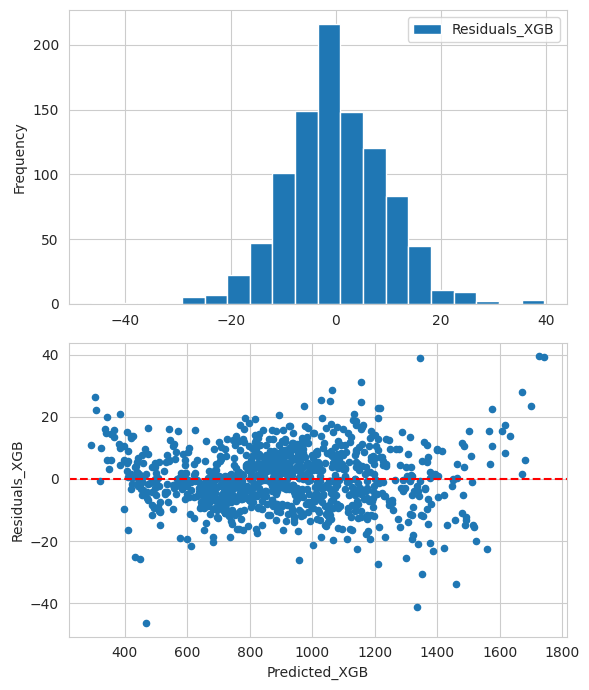

In [247]:
fig, ((g1), (g2)) = plt.subplots(2, 1, figsize = (6,7))
data.plot(y = "Residuals_XGB", kind = "hist", bins = 20, ax = g1)
data.plot(x = "Predicted_XGB", y = "Residuals_XGB", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
fig.tight_layout()
plt.show()

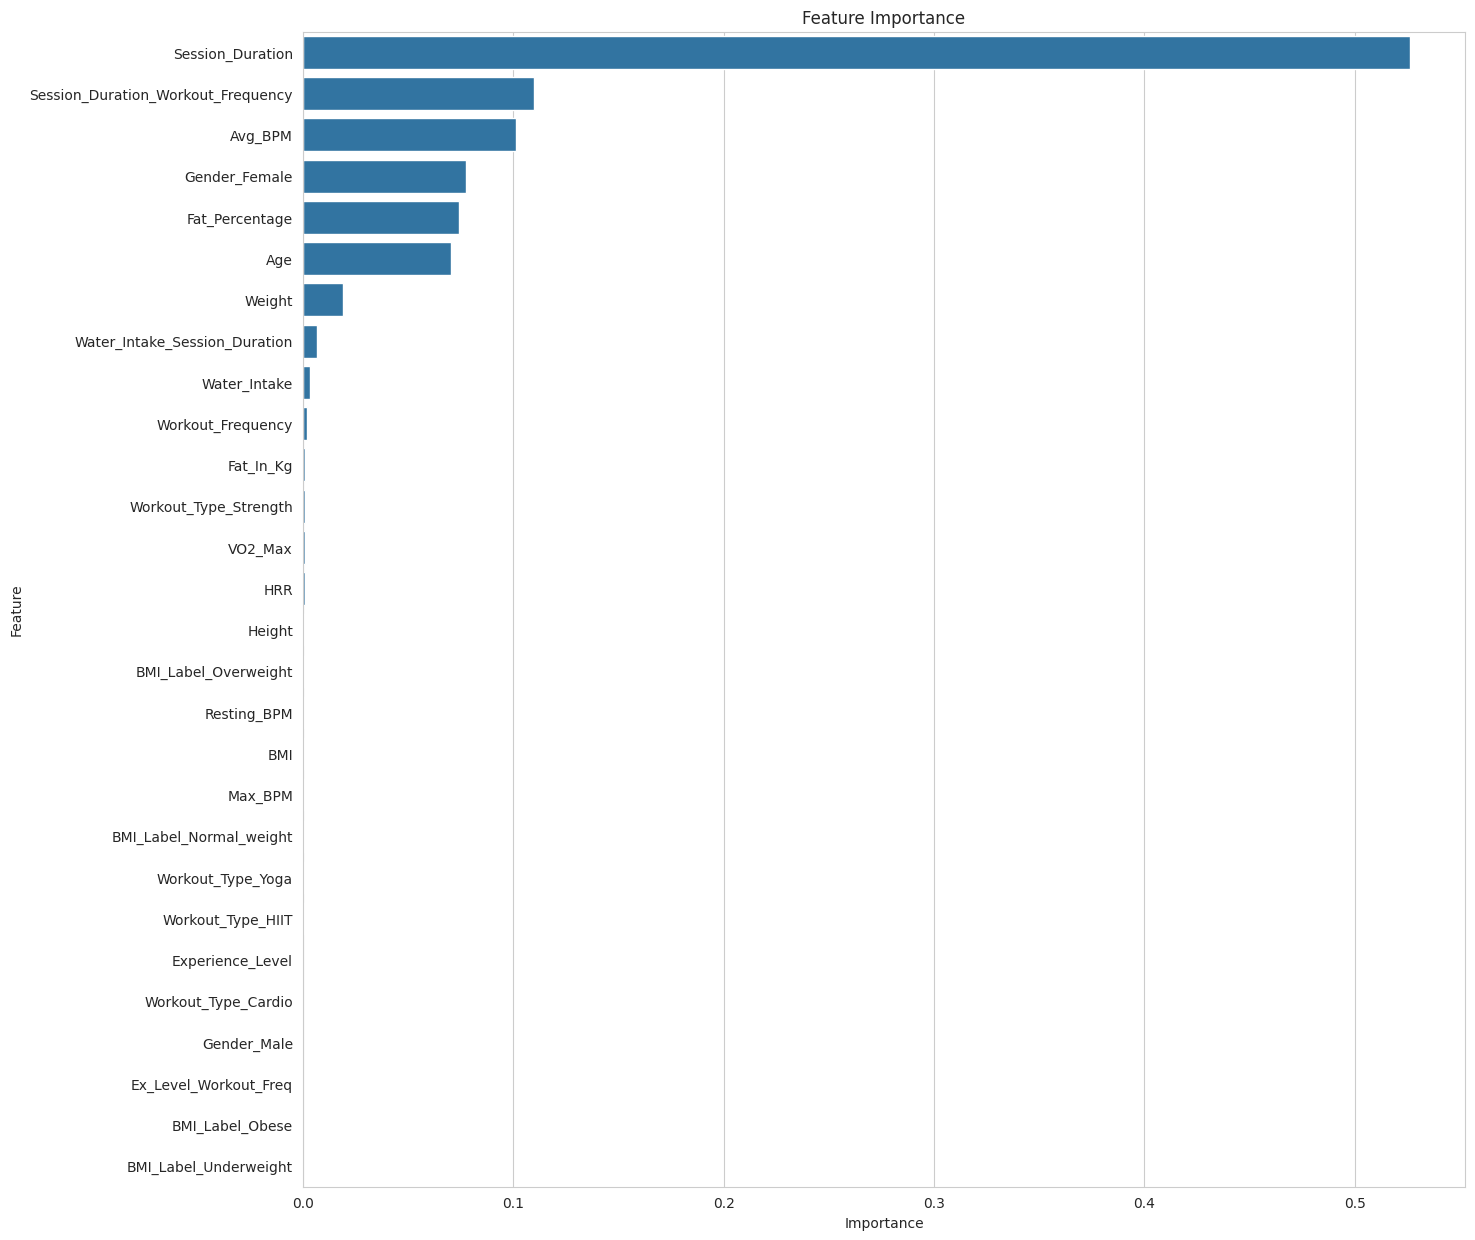

In [248]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize = (15, 15))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.show()

In [249]:
feature_importances[feature_importances["Importance"] > 0.05]

,Feature,Importance
0,Session_Duration,0.526222
27,Session_Duration_Workout_Frequency,0.109747
2,Avg_BPM,0.101306
12,Gender_Female,0.077424
1,Fat_Percentage,0.074445
4,Age,0.070345


In [250]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
    'max_depth': [2, 3, 4, 5,6,7,None],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [2,4,6,8,10, 12, 14, 16],
    'lambda': [1, 2, 3, 4, 5.0, 6.0, 7.0], 
    'alpha': [1, 2, 3, 4, 5.0, 6.0, 7.0]   
}

X = data_pom[[ "Session_Duration", "Session_Duration_Workout_Frequency", "Avg_BPM", "Gender_Female", "Fat_Percentage", "Age"]]
y = data_pom['Calories_Burned']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = xgb.XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,  
    scoring='neg_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y)

best_xgb_model = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

train_mse_scores, test_mse_scores = [], []
train_rse_scores, test_rse_scores = [], []
train_mae_scores, test_mae_scores = [], []
train_rmse_scores, test_rmse_scores = [], []
train_r2_scores, test_r2_scores = [], []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    best_xgb_model.fit(X_train, y_train)
    train_predictions = best_xgb_model.predict(X_train)
    test_predictions = best_xgb_model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    train_mse_scores.append(train_mse)
    test_mse_scores.append(test_mse)

    train_rse = calculate_rse(y_train, train_predictions)
    test_rse = calculate_rse(y_test, test_predictions)
    train_rse_scores.append(train_rse)
    test_rse_scores.append(test_rse)

    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae = mean_absolute_error(y_test, test_predictions)
    train_mae_scores.append(train_mae)
    test_mae_scores.append(test_mae)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_rmse_scores.append(train_rmse)
    test_rmse_scores.append(test_rmse)

    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

results_df = pd.DataFrame({
    "Metric": ["Train_MSE", "Test_MSE", "Train_RMSE", "Test_RMSE", "Train_MAE", "Test_MAE", "Train_R2", "Test_R2", "Train_RSE", "Test_RSE"],
    "Mean": [
        np.mean(train_mse_scores),
        np.mean(test_mse_scores),
        np.mean(train_rmse_scores),
        np.mean(test_rmse_scores),
        np.mean(train_mae_scores),
        np.mean(test_mae_scores),
        np.mean(train_r2_scores),
        np.mean(test_r2_scores),
        np.mean(train_rse_scores),
        np.mean(test_rse_scores)
    ],
    "Std": [
        np.std(train_mse_scores),
        np.std(test_mse_scores),
        np.std(train_rmse_scores),
        np.std(test_rmse_scores),
        np.std(train_mae_scores),
        np.std(test_mae_scores),
        np.std(train_r2_scores),
        np.std(test_r2_scores),
        np.std(train_rse_scores),
        np.std(test_rse_scores)
    ]
})

print(results_df)



Best parameters: {'subsample': 0.6, 'n_estimators': 700, 'min_child_weight': 12, 'max_depth': 2, 'learning_rate': 0.05, 'lambda': 3, 'colsample_bytree': 1.0, 'alpha': 1}
       Metric        Mean        Std
0   Train_MSE   83.271416   4.348662
1    Test_MSE  179.421567  43.240377
2  Train_RMSE    9.122136   0.240930
3   Test_RMSE   13.303616   1.560568
4   Train_MAE    7.065970   0.239576
5    Test_MAE    9.976807   0.993731
6    Train_R2    0.998879   0.000048
7     Test_R2    0.997586   0.000554
8   Train_RSE    9.128001   0.241083
9    Test_RSE   13.337925   1.564539


In [251]:
best_xgb_model.fit(X, y)
data["Predicted_XGB"] = best_xgb_model.predict(X)
data["Residuals_XGB"] = data["Calories_Burned"] - data["Predicted_XGB"]
std_residuals = data["Residuals_XGB"].std()
data["Std_Residuals_XGB"] = data["Residuals_XGB"] / std_residuals
data

,Age,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,...,BMI_Label_Obese,BMI_Label_Overweight,BMI_Label_Underweight,Predicted,Residuals,Std_Residuals,Calories_Burned_SQRT,Predicted_XGB,Residuals_XGB,Std_Residuals_XGB
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,...,True,False,False,1342.779120,-29.779120,-0.558178,36.235342,1309.335571,3.664429,0.435347
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,...,True,False,False,926.891214,-43.891214,-0.646467,29.715316,890.838928,-7.838928,-0.931292
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,...,False,False,False,624.228192,52.771808,0.758985,26.019224,676.819031,0.180969,0.021500
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,...,False,False,True,545.352259,-13.352259,-0.282264,23.065125,534.345398,-2.345398,-0.278642
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,...,False,False,True,568.662794,-12.662794,-0.235008,23.579652,575.879150,-19.879150,-2.361713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,...,False,True,False,1273.296067,90.703933,1.364458,36.932371,1370.075439,-6.075439,-0.721784
969,25,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,...,False,True,False,1160.147458,99.852542,1.240036,35.496479,1248.776367,11.223633,1.333407
970,59,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,...,False,False,False,1074.123184,-145.123184,-1.940721,30.479501,917.066284,11.933716,1.417767
971,32,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,...,True,False,False,781.673953,101.326047,1.929249,29.715316,881.033325,1.966675,0.233648


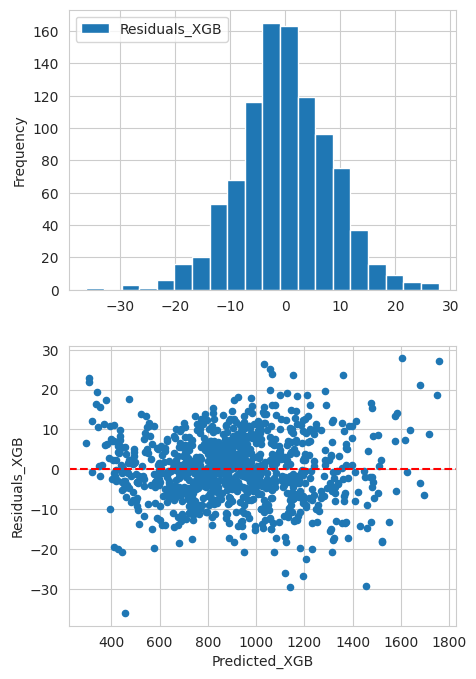

In [252]:
fig, ((g1), (g2)) = plt.subplots(2,1, figsize = (5,8))
data.plot(y = "Residuals_XGB", kind = "hist", bins = 20, ax = g1)
data.plot(x = "Predicted_XGB", y = "Residuals_XGB", kind = "scatter", ax = g2)
g2.axhline(y = 0, c = "red", linestyle = "dashed")
plt.show()
